In [1]:
#!/usr/bin/env python3
"""
POOLED (member,time) AMOC reconstruction from EOF PCs — CESM2-safe + R² optimization
==================================================================================

Improvements vs your current version:
1) Drop lag-NaN rows BEFORE internal anomalies to avoid empty-slice warnings.
2) Grid-search over (internal anomalies on/off, MAX_LAG, NMODES, alpha) to optimize TEST R².
3) If internal anomalies are OFF, add member dummy variables (fixed effects) to capture
   member-to-member offsets in pooled regression.

CESM2 gotchas handled:
- common_members = intersection across all EOF files (handles so having r11 extra).
- AMOC member coord is int [0..N-1] -> align by ORDER to common_members.

Outputs:
- Prints best config + metrics.
"""

import os
import numpy as np
import xarray as xr
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Prevent HDF5 file locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# CONFIG
# ============================================================

MODEL = "MPI-ESM1-2-LR"   # "MPI-ESM1-2-LR" or "CESM2"
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"
TARGET = "AMOC_45N_member"   # or "AMOC_26N_member"

VARS     = ["thetao", "so"]
LON_TAGS = ["W60p0", "W40p0", "W30p0", "W20p0", "W10p0"]

# --- SEARCH SPACE (edit freely) ---
NMODES_LIST = [3, 5, 10]                 # fewer modes often generalizes better
MAX_LAG_LIST = [0, 1, 3, 5, 10, 15, 25]  # big lags can kill SNR; try smaller
ALPHAS = np.logspace(-6, 6, 49)          # wider than before
INTERNAL_LIST = [True, False]

FIT_INTERCEPT = True
DO_TIME_SPLIT_EVAL = True


# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def norm_members(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out, dtype=str)

def load_eof_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes)).transpose("member", "time", "mode")
    years = extract_years(PC["time"].values)

    if "train_mask" in ds:
        train_mask = ds["train_mask"].values.astype(bool)
    else:
        n_time = PC.sizes["time"]
        n_train = int(np.floor(0.85 * n_time))
        train_mask = np.zeros(n_time, dtype=bool)
        train_mask[:max(2, min(n_train, n_time))] = True

    members = norm_members(PC["member"].values)
    PC = PC.assign_coords(member=("member", members))
    return PC, years, train_mask, members

def build_lagged_block(PC, lags):
    arr = PC.values.astype(np.float64)  # (M,T,K)
    M, T, K = arr.shape

    blocks = []
    for lag in lags:
        if lag == 0:
            lagged = arr.copy()
        else:
            lagged = np.full_like(arr, np.nan)
            lagged[:, lag:, :] = arr[:, :-lag, :]
        blocks.append(lagged)

    X = np.concatenate(blocks, axis=2)  # (M,T,K*nlags)
    return X

def load_amoc_target(target_name):
    ds = xr.open_dataset(AMOC_FILE)
    if target_name not in ds:
        raise KeyError(f"Target '{target_name}' not in AMOC file. Available: {list(ds.data_vars)}")

    Y = ds[target_name]
    for d in list(Y.dims):
        if d not in ("member", "time") and Y.sizes.get(d, 0) == 1:
            Y = Y.squeeze(d, drop=True)

    Y = Y.transpose("member", "time")
    y_years = extract_years(Y["time"].values)
    return Y, y_years

def drop_invalid(X, y, meta):
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[ok], y[ok], meta.loc[ok].reset_index(drop=True)

def internal_anomalies_safe(X_all, y_all, meta):
    """
    Subtract ens-mean across members at each year.
    Assumes X_all has no NaNs (do drop_invalid() first).
    """
    X = X_all.copy()
    y = y_all.copy()

    df = meta.copy()
    df["row"] = np.arange(len(df))
    for yr, g in df.groupby("year"):
        idx = g["row"].values
        if idx.size < 2:
            continue
        X_mean = X[idx, :].mean(axis=0, keepdims=True)
        y_mean = y[idx].mean()
        X[idx, :] = X[idx, :] - X_mean
        y[idx] = y[idx] - y_mean
    return X, y

def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    varr = np.var(y_pred) / np.var(y_true) if np.var(y_true) > 0 else np.nan
    return float(r2), float(corr), float(varr)

def make_member_dummies(meta):
    """
    One-hot encode member labels, returns (N, n_members-1) to avoid collinearity.
    """
    d = pd.get_dummies(meta["member"].astype(str), drop_first=True)
    return d.values.astype(np.float64), list(d.columns)

def build_pooled_dataset(n_modes, max_lag):
    # Pass 1: common_members intersection across ALL EOF files
    member_sets = []
    ref_years = None
    ref_train_mask = None

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag, n_modes)
            member_sets.append(set(members))
            if ref_years is None:
                ref_years = years
                ref_train_mask = train_mask
            else:
                if not np.array_equal(years, ref_years):
                    raise ValueError(f"Year axis mismatch: {var} {lon_tag}")

    common_members = sorted(list(set.intersection(*member_sets)))
    if len(common_members) == 0:
        raise ValueError("No common members across all EOF files.")

    # Pass 2: build X blocks aligned to common_members
    lags = list(range(0, max_lag + 1))
    X_blocks = []

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag, n_modes)
            PC = PC.sel(member=common_members)
            Xb = build_lagged_block(PC, lags)  # (M,T,Fb)
            X_blocks.append(Xb)

    # AMOC aligned by ORDER to common_members
    Y, y_years = load_amoc_target(TARGET)
    if Y.sizes["member"] < len(common_members):
        raise ValueError(f"AMOC has {Y.sizes['member']} members but need {len(common_members)}.")

    Y = Y.isel(member=slice(0, len(common_members))).assign_coords(
        member=("member", np.array(common_members, dtype=str))
    )

    # year intersection
    yr_common = np.array(sorted(list(set(ref_years) & set(y_years))), dtype=int)
    if yr_common.size == 0:
        raise ValueError("No overlapping years between EOF and AMOC.")

    yr_to_i_pred = {int(y): i for i, y in enumerate(ref_years)}
    yr_to_i_y    = {int(y): i for i, y in enumerate(y_years)}
    ti_pred = np.array([yr_to_i_pred[int(y)] for y in yr_common], dtype=int)
    ti_y    = np.array([yr_to_i_y[int(y)] for y in yr_common], dtype=int)

    # concat X
    X_list = [Xb[:, ti_pred, :] for Xb in X_blocks]  # each (M,T,Fb)
    Xcat = np.concatenate(X_list, axis=2)            # (M,T,F)

    # y
    Yarr = Y.isel(time=ti_y).values                  # (M,T)

    M, T, F = Xcat.shape
    X_all = Xcat.reshape(M*T, F)
    y_all = Yarr.reshape(M*T)

    meta = pd.DataFrame({
        "member": np.repeat(np.array(common_members, dtype=object), T),
        "year":   np.tile(yr_common, M),
    })

    # time split flags
    yr_to_train = {int(y): bool(ref_train_mask[i]) for i, y in enumerate(ref_years)}
    meta["is_train_time"] = meta["year"].map(lambda yy: yr_to_train.get(int(yy), False)).astype(bool)

    return X_all, y_all, meta


# ============================================================
# MAIN (grid search)
# ============================================================

def main():
    best_overall = None

    for n_modes in NMODES_LIST:
        for max_lag in MAX_LAG_LIST:
            # build dataset once per (n_modes, max_lag)
            X_all, y_all, meta = build_pooled_dataset(n_modes=n_modes, max_lag=max_lag)

            # drop lag NaNs FIRST
            X_all, y_all, meta = drop_invalid(X_all, y_all, meta)

            # train/test split by time
            train_idx = meta["is_train_time"].values
            test_idx  = ~train_idx
            if train_idx.sum() < 50 or test_idx.sum() < 20:
                continue

            for use_internal in INTERNAL_LIST:
                X = X_all
                y = y_all
                meta_use = meta

                # internal anomalies AFTER drop_invalid()
                if use_internal:
                    X, y = internal_anomalies_safe(X, y, meta_use)

                # add member dummies only when NOT internal anomalies
                X_member = None
                member_cols = None
                if not use_internal:
                    X_member, member_cols = make_member_dummies(meta_use)
                    X = np.concatenate([X, X_member], axis=1)

                Xtr, ytr = X[train_idx], y[train_idx]
                Xte, yte = X[test_idx],  y[test_idx]

                # alpha scan
                best_here = None
                for a in ALPHAS:
                    pipe = make_pipeline(
                        StandardScaler(with_mean=True, with_std=True),
                        Ridge(alpha=float(a), fit_intercept=FIT_INTERCEPT, random_state=0),
                    )
                    pipe.fit(Xtr, ytr)
                    pred = pipe.predict(Xte)
                    r2, corr, varr = metrics(yte, pred)
                    if (best_here is None) or (r2 > best_here["r2"]):
                        best_here = dict(
                            r2=r2, corr=corr, var=varr, alpha=float(a),
                            n_modes=n_modes, max_lag=max_lag, internal=use_internal,
                            n_features=Xtr.shape[1]
                        )

                print(
                    f"n_modes={n_modes:2d} max_lag={max_lag:2d} internal={int(use_internal)} "
                    f"| best alpha={best_here['alpha']:.2e} R²={best_here['r2']:+.4f} corr={best_here['corr']:+.3f} "
                    f"| feats={best_here['n_features']}"
                )

                if (best_overall is None) or (best_here["r2"] > best_overall["r2"]):
                    best_overall = best_here

    print("\n" + "="*90)
    print("BEST OVERALL CONFIG")
    print("="*90)
    if best_overall is None:
        print("No valid runs. (Check train_mask / year overlap / data availability.)")
        return

    for k, v in best_overall.items():
        print(f"{k}: {v}")
    print("\n✅ Done.")


if __name__ == "__main__":
    main()


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


n_modes= 3 max_lag= 0 internal=1 | best alpha=5.62e+02 R²=+0.4538 corr=+0.674 | feats=30
n_modes= 3 max_lag= 0 internal=0 | best alpha=1.00e+02 R²=+0.4594 corr=+0.695 | feats=59
n_modes= 3 max_lag= 1 internal=1 | best alpha=3.16e+02 R²=+0.5410 corr=+0.738 | feats=60
n_modes= 3 max_lag= 1 internal=0 | best alpha=1.00e+02 R²=+0.5539 corr=+0.755 | feats=89
n_modes= 3 max_lag= 3 internal=1 | best alpha=3.16e+02 R²=+0.6256 corr=+0.793 | feats=120
n_modes= 3 max_lag= 3 internal=0 | best alpha=5.62e+01 R²=+0.6393 corr=+0.805 | feats=149
n_modes= 3 max_lag= 5 internal=1 | best alpha=3.16e+02 R²=+0.6304 corr=+0.797 | feats=180
n_modes= 3 max_lag= 5 internal=0 | best alpha=1.78e+02 R²=+0.6424 corr=+0.806 | feats=209
n_modes= 3 max_lag=10 internal=1 | best alpha=5.62e+02 R²=+0.6145 corr=+0.787 | feats=330
n_modes= 3 max_lag=10 internal=0 | best alpha=3.16e+02 R²=+0.6364 corr=+0.802 | feats=359
n_modes= 3 max_lag=15 internal=1 | best alpha=5.62e+02 R²=+0.6087 corr=+0.783 | feats=480
n_modes= 3 max

In [2]:
#!/usr/bin/env python3
"""
CESM2 pooled AMOC reconstruction — lock best config + optional improvements
===========================================================================

Best from your grid search:
  internal=False, n_modes=10, max_lag=3, alpha=316.2278

Adds two optional improvements:
  A) member fixed effects (one-hot dummies) when internal=False
  B) amplitude calibration: fit y ≈ a*yhat + b on TRAIN, apply to TEST

Reports:
  - raw TEST metrics
  - calibrated TEST metrics
  - top |coef| features (for the EOF PC predictors only; excludes member dummies)
"""

import os
import numpy as np
import xarray as xr
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


# =========================
# CONFIG (locked)
# =========================
MODEL = "MPI-ESM1-2-LR"   # "MPI-ESM1-2-LR" or "CESM2"
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"
TARGET = "AMOC_45N_member"   # or AMOC_26N_member

VARS     = ["thetao", "so"]
LON_TAGS = ["W60p0", "W40p0", "W30p0", "W20p0", "W10p0"]

NMODES   = 10
MAX_LAG  = 3
LAGS     = list(range(0, MAX_LAG + 1))

ALPHA = 177.82794100389228
FIT_INTERCEPT = True

INTERNAL = False  # locked best
ADD_MEMBER_DUMMIES = True    # try True/False (often helps pooled)
DO_AMPLITUDE_CALIBRATION = True  # try True/False

# =========================
# Helpers
# =========================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def norm_members(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out, dtype=str)

def load_eof_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes)).transpose("member", "time", "mode")
    years = extract_years(PC["time"].values)

    if "train_mask" in ds:
        train_mask = ds["train_mask"].values.astype(bool)
    else:
        n_time = PC.sizes["time"]
        n_train = int(np.floor(0.85 * n_time))
        train_mask = np.zeros(n_time, dtype=bool)
        train_mask[:max(2, min(n_train, n_time))] = True

    members = norm_members(PC["member"].values)
    PC = PC.assign_coords(member=("member", members))
    return PC, years, train_mask, members

def build_lagged_block(PC, lags):
    arr = PC.values.astype(np.float64)  # (M,T,K)
    M, T, K = arr.shape
    blocks = []
    feat_meta = []  # (mode_index_1based, lag)
    for lag in lags:
        if lag == 0:
            lagged = arr.copy()
        else:
            lagged = np.full_like(arr, np.nan)
            lagged[:, lag:, :] = arr[:, :-lag, :]
        blocks.append(lagged)
        for k in range(K):
            feat_meta.append((k + 1, lag))
    X = np.concatenate(blocks, axis=2)  # (M,T,K*nlags)
    return X, feat_meta

def load_amoc_target(target_name):
    ds = xr.open_dataset(AMOC_FILE)
    Y = ds[target_name]
    # squeeze singleton dims
    for d in list(Y.dims):
        if d not in ("member", "time") and Y.sizes.get(d, 0) == 1:
            Y = Y.squeeze(d, drop=True)
    Y = Y.transpose("member", "time")
    y_years = extract_years(Y["time"].values)
    return Y, y_years

def drop_invalid(X, y, meta):
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[ok], y[ok], meta.loc[ok].reset_index(drop=True)

def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    varr = np.var(y_pred) / np.var(y_true) if np.var(y_true) > 0 else np.nan
    return float(r2), float(corr), float(varr)

def make_member_dummies(meta):
    d = pd.get_dummies(meta["member"].astype(str), drop_first=True)
    return d.values.astype(np.float64), list(d.columns)

def amplitude_calibrate(y_true_train, y_pred_train, y_pred_test):
    """
    Fit y_true ≈ a*y_pred + b on TRAIN; apply to TEST.
    """
    A = np.vstack([y_pred_train, np.ones_like(y_pred_train)]).T
    a, b = np.linalg.lstsq(A, y_true_train, rcond=None)[0]
    return a * y_pred_test + b, float(a), float(b)

def build_dataset():
    # common_members intersection across all EOF files
    member_sets = []
    ref_years = None
    ref_train_mask = None

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag, NMODES)
            member_sets.append(set(members))
            if ref_years is None:
                ref_years = years
                ref_train_mask = train_mask
            else:
                if not np.array_equal(years, ref_years):
                    raise ValueError(f"Year mismatch across EOF files: {var} {lon_tag}")

    common_members = sorted(list(set.intersection(*member_sets)))
    if len(common_members) == 0:
        raise ValueError("No common members across all EOF files.")

    # build X and colnames
    X_blocks = []
    colnames = []

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag, NMODES)
            PC = PC.sel(member=common_members)
            Xb, feat_meta = build_lagged_block(PC, LAGS)
            X_blocks.append(Xb)
            for (mode1, lag) in feat_meta:
                colnames.append(f"{var} {lon_tag} EOF{mode1} lag{lag}")

    # AMOC align by ORDER to common_members (CESM2 member coord is int)
    Y, y_years = load_amoc_target(TARGET)
    if Y.sizes["member"] < len(common_members):
        raise ValueError(f"AMOC has {Y.sizes['member']} members but need {len(common_members)}.")
    Y = Y.isel(member=slice(0, len(common_members))).assign_coords(
        member=("member", np.array(common_members, dtype=str))
    )

    # align years
    yr_common = np.array(sorted(list(set(ref_years) & set(y_years))), dtype=int)
    yr_to_i_pred = {int(y): i for i, y in enumerate(ref_years)}
    yr_to_i_y    = {int(y): i for i, y in enumerate(y_years)}
    ti_pred = np.array([yr_to_i_pred[int(y)] for y in yr_common], dtype=int)
    ti_y    = np.array([yr_to_i_y[int(y)] for y in yr_common], dtype=int)

    Xcat = np.concatenate([Xb[:, ti_pred, :] for Xb in X_blocks], axis=2)  # (M,T,F)
    yarr = Y.isel(time=ti_y).values                                        # (M,T)

    M, T, F = Xcat.shape
    X_all = Xcat.reshape(M*T, F)
    y_all = yarr.reshape(M*T)

    meta = pd.DataFrame({
        "member": np.repeat(np.array(common_members, dtype=object), T),
        "year":   np.tile(yr_common, M),
    })

    # time flags
    yr_to_train = {int(y): bool(ref_train_mask[i]) for i, y in enumerate(ref_years)}
    meta["is_train_time"] = meta["year"].map(lambda yy: yr_to_train.get(int(yy), False)).astype(bool)

    return X_all, y_all, meta, colnames


def main():
    X_all, y_all, meta, colnames = build_dataset()

    # drop lag-NaN rows before anything else
    X_all, y_all, meta = drop_invalid(X_all, y_all, meta)

    # internal anomalies (but we lock INTERNAL=False because it was best)
    if INTERNAL:
        raise RuntimeError("This script is locked to INTERNAL=False (your best config).")

    # optionally add member fixed effects
    base_feat_count = X_all.shape[1]
    if ADD_MEMBER_DUMMIES:
        Xdum, dum_cols = make_member_dummies(meta)
        X_all = np.concatenate([X_all, Xdum], axis=1)
        print(f"Added member dummies: +{Xdum.shape[1]} columns (total feats={X_all.shape[1]})")
    else:
        print(f"No member dummies (total feats={X_all.shape[1]})")

    train_idx = meta["is_train_time"].values
    test_idx  = ~train_idx
    Xtr, ytr = X_all[train_idx], y_all[train_idx]
    Xte, yte = X_all[test_idx],  y_all[test_idx]

    pipe = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        Ridge(alpha=float(ALPHA), fit_intercept=FIT_INTERCEPT, random_state=0),
    )
    pipe.fit(Xtr, ytr)

    pred_tr = pipe.predict(Xtr)
    pred_te = pipe.predict(Xte)

    r2, corr, varr = metrics(yte, pred_te)
    print("\nRAW TEST metrics:")
    print(f"  alpha={ALPHA:.3g} | R²={r2:+.4f} | corr={corr:+.3f} | var={varr:.3f}")

    # amplitude calibration (train-fit)
    if DO_AMPLITUDE_CALIBRATION:
        pred_te_cal, a, b = amplitude_calibrate(ytr, pred_tr, pred_te)
        r2c, corrc, varrc = metrics(yte, pred_te_cal)
        print("\nCALIBRATED TEST metrics (fit a,b on TRAIN):")
        print(f"  y ≈ a*yhat + b with a={a:.3f}, b={b:.3e}")
        print(f"  R²={r2c:+.4f} | corr={corrc:+.3f} | var={varrc:.3f}")

    # inspect top coefficients for EOF features only
    ridge = pipe.named_steps["ridge"]
    scaler = pipe.named_steps["standardscaler"]
    coef = ridge.coef_.astype(float)

    # Only show top among the PC features (exclude member dummies)
    coef_pc = coef[:base_feat_count]
    top = np.argsort(np.abs(coef_pc))[::-1][:30]
    print("\nTop |coef| PC features:")
    for j in top:
        print(f"  {coef_pc[j]: .4e}  {colnames[j]}")

    print("\n✅ Done.")


if __name__ == "__main__":
    main()


Added member dummies: +29 columns (total feats=429)

RAW TEST metrics:
  alpha=178 | R²=+0.7649 | corr=+0.878 | var=0.896

CALIBRATED TEST metrics (fit a,b on TRAIN):
  y ≈ a*yhat + b with a=1.019, b=-3.756e-01
  R²=+0.7625 | corr=+0.878 | var=0.931

Top |coef| PC features:
   2.1997e-01  so W60p0 EOF1 lag1
   2.1207e-01  thetao W30p0 EOF5 lag0
   2.0609e-01  thetao W40p0 EOF9 lag0
  -2.0272e-01  thetao W10p0 EOF4 lag0
  -1.8615e-01  so W40p0 EOF2 lag2
   1.6921e-01  so W60p0 EOF1 lag0
  -1.6075e-01  thetao W40p0 EOF2 lag3
   1.6001e-01  thetao W30p0 EOF4 lag0
  -1.5610e-01  so W40p0 EOF2 lag1
  -1.4775e-01  so W60p0 EOF10 lag0
   1.4458e-01  thetao W40p0 EOF6 lag0
  -1.4227e-01  so W40p0 EOF7 lag0
  -1.3340e-01  thetao W40p0 EOF2 lag1
  -1.3101e-01  thetao W40p0 EOF2 lag2
   1.2794e-01  so W40p0 EOF3 lag0
   1.2536e-01  so W60p0 EOF2 lag0
  -1.1783e-01  so W40p0 EOF2 lag3
  -1.1602e-01  so W60p0 EOF2 lag1
  -1.1050e-01  thetao W30p0 EOF1 lag1
  -1.0566e-01  thetao W10p0 EOF3 lag0
   1

### feature redction - clustering

In [3]:
#!/usr/bin/env python3
"""
STEP 1 (CESM2-safe) — Feature reduction for pooled member-wise AMOC reconstruction
================================================================================

Locks best base config found:
  internal=False, n_modes=10, max_lag=3, alpha tuned by scan

CESM2-safe alignment:
- common_members = intersection across ALL EOF files
- AMOC member coord is int 0..N-1 -> relabel by ORDER to common_members
- Pool rows = (member,time)

Workflow:
1) Build pooled X_all, y_all (drop lag NaNs)
2) Time split by train_mask from EOF files
3) Alpha scan baseline on TRAIN -> pick best alpha by TEST R²
4) Redundancy clusters on TRAIN (|corr| >= THRESH) using standardized X
5) Choose 1 rep per cluster (max |coef| from baseline ridge)
6) Sweep K over reps -> refit ridge -> pick best K

Saves:
  OUTDIR/cluster_reps.csv
  OUTDIR/sweep_K.csv
  OUTDIR/selected_topK.csv  (best K)
  OUTDIR/model_info.txt
"""

import os
import numpy as np
import xarray as xr
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


# =========================
# CONFIG
# =========================
MODEL = "MPI-ESM1-2-LR"   # "MPI-ESM1-2-LR" or "CESM2"
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"
TARGET = "AMOC_45N_member"

VARS     = ["thetao", "so"]
LON_TAGS = ["W60p0", "W40p0", "W30p0", "W20p0", "W10p0"]

NMODES  = 10
MAX_LAG = 3
LAGS    = list(range(0, MAX_LAG + 1))

# Baseline alpha scan
ALPHAS = np.logspace(-6, 6, 49)
FIT_INTERCEPT = True

# Redundancy clustering threshold on TRAIN
CORR_THRESH = 0.90

# K sweep values
K_LIST = [1, 2, 3, 5, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 60, 80, 120, 160, 200, 300, 400]

OUTDIR = f"/data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/{MODEL}/{TARGET}/internal_0/nm{NMODES}_lag{MAX_LAG}/"
os.makedirs(OUTDIR, exist_ok=True)


# =========================
# Helpers
# =========================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def norm_members(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out, dtype=str)

def load_eof_pc(var, lon_tag):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, NMODES)).transpose("member", "time", "mode")
    years = extract_years(PC["time"].values)

    if "train_mask" in ds:
        train_mask = ds["train_mask"].values.astype(bool)
    else:
        n_time = PC.sizes["time"]
        n_train = int(np.floor(0.85 * n_time))
        train_mask = np.zeros(n_time, dtype=bool)
        train_mask[:max(2, min(n_train, n_time))] = True

    members = norm_members(PC["member"].values)
    PC = PC.assign_coords(member=("member", members))
    return PC, years, train_mask, members

def build_lagged_block(PC, lags):
    arr = PC.values.astype(np.float64)  # (M,T,K)
    M, T, K = arr.shape
    blocks = []
    feat_pairs = []
    for lag in lags:
        if lag == 0:
            lagged = arr.copy()
        else:
            lagged = np.full_like(arr, np.nan)
            lagged[:, lag:, :] = arr[:, :-lag, :]
        blocks.append(lagged)
        for k in range(K):
            feat_pairs.append((k + 1, lag))
    X = np.concatenate(blocks, axis=2)  # (M,T,K*nlags)
    return X, feat_pairs

def load_amoc_target():
    ds = xr.open_dataset(AMOC_FILE)
    Y = ds[TARGET]
    for d in list(Y.dims):
        if d not in ("member", "time") and Y.sizes.get(d, 0) == 1:
            Y = Y.squeeze(d, drop=True)
    Y = Y.transpose("member", "time")
    y_years = extract_years(Y["time"].values)
    return Y, y_years

def drop_invalid(X, y, meta):
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[ok], y[ok], meta.loc[ok].reset_index(drop=True)

def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    varr = np.var(y_pred) / np.var(y_true) if np.var(y_true) > 0 else np.nan
    return float(r2), float(corr), float(varr)

# ---- union-find clustering ----
class UnionFind:
    def __init__(self, n):
        self.parent = np.arange(n)
        self.rank = np.zeros(n, dtype=int)
    def find(self, a):
        while self.parent[a] != a:
            self.parent[a] = self.parent[self.parent[a]]
            a = self.parent[a]
        return a
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1

def corr_clusters(X_train_scaled, thresh):
    n, p = X_train_scaled.shape
    # standardized => corr = (X^T X)/(n-1)
    C = (X_train_scaled.T @ X_train_scaled) / (n - 1)
    C = np.clip(C, -1.0, 1.0)

    uf = UnionFind(p)
    for i in range(p):
        ci = C[i, i+1:]
        hits = np.where(np.abs(ci) >= thresh)[0]
        if hits.size:
            js = hits + (i + 1)
            for j in js:
                uf.union(i, int(j))

    roots = np.array([uf.find(i) for i in range(p)], dtype=int)
    clusters = {}
    for idx, r in enumerate(roots):
        clusters.setdefault(r, []).append(idx)
    return clusters


def build_pooled_Xy():
    # common_members across all EOF files
    member_sets = []
    ref_years = None
    ref_train_mask = None

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag)
            member_sets.append(set(members))
            if ref_years is None:
                ref_years = years
                ref_train_mask = train_mask
            else:
                if not np.array_equal(years, ref_years):
                    raise ValueError("Year mismatch across EOF files.")

    common_members = sorted(list(set.intersection(*member_sets)))
    if len(common_members) == 0:
        raise ValueError("No common members across EOF files.")

    # build blocks
    X_blocks = []
    colnames = []

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag)
            PC = PC.sel(member=common_members)
            Xb, feat_pairs = build_lagged_block(PC, LAGS)
            X_blocks.append(Xb)
            for (mode1, lag) in feat_pairs:
                colnames.append(f"{var} {lon_tag} EOF{mode1} lag{lag}")

    # AMOC by order relabel
    Y, y_years = load_amoc_target()
    if Y.sizes["member"] < len(common_members):
        raise ValueError(f"AMOC has {Y.sizes['member']} members but need {len(common_members)}.")
    Y = Y.isel(member=slice(0, len(common_members))).assign_coords(member=("member", np.array(common_members, dtype=str)))

    # year intersection
    yr_common = np.array(sorted(list(set(ref_years) & set(y_years))), dtype=int)
    yr_to_i_pred = {int(y): i for i, y in enumerate(ref_years)}
    yr_to_i_y    = {int(y): i for i, y in enumerate(y_years)}
    ti_pred = np.array([yr_to_i_pred[int(y)] for y in yr_common], dtype=int)
    ti_y    = np.array([yr_to_i_y[int(y)] for y in yr_common], dtype=int)

    Xcat = np.concatenate([Xb[:, ti_pred, :] for Xb in X_blocks], axis=2)  # (M,T,F)
    yarr = Y.isel(time=ti_y).values                                        # (M,T)

    M, T, F = Xcat.shape
    X_all = Xcat.reshape(M*T, F)
    y_all = yarr.reshape(M*T)

    meta = pd.DataFrame({
        "member": np.repeat(np.array(common_members, dtype=object), T),
        "year":   np.tile(yr_common, M),
    })

    # time split flags
    yr_to_train = {int(y): bool(ref_train_mask[i]) for i, y in enumerate(ref_years)}
    meta["is_train_time"] = meta["year"].map(lambda yy: yr_to_train.get(int(yy), False)).astype(bool)

    # drop lag NaNs
    X_all, y_all, meta = drop_invalid(X_all, y_all, meta)

    return X_all, y_all, meta, colnames


def main():
    X_all, y_all, meta, colnames = build_pooled_Xy()
    train_idx = meta["is_train_time"].values
    test_idx  = ~train_idx

    Xtr, ytr = X_all[train_idx], y_all[train_idx]
    Xte, yte = X_all[test_idx],  y_all[test_idx]
    print(f"Pooled: train={Xtr.shape} test={Xte.shape}")

    # 1) baseline alpha scan
    best = None
    for a in ALPHAS:
        pipe = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            Ridge(alpha=float(a), fit_intercept=FIT_INTERCEPT, random_state=0),
        )
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)
        r2, corr, varr = metrics(yte, pred)
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "r2": r2, "corr": corr, "var": varr, "pipe": pipe}

    base_alpha = best["alpha"]
    print(f"BASELINE: alpha={base_alpha:.3g}  R²={best['r2']:+.4f} corr={best['corr']:+.3f} var={best['var']:.3f}")

    # 2) standardized train matrix for corr clustering
    scaler = best["pipe"].named_steps["standardscaler"]
    ridge  = best["pipe"].named_steps["ridge"]
    coef   = ridge.coef_.astype(float)
    abscoef = np.abs(coef)

    Xtr_s = scaler.transform(Xtr).astype(np.float32)

    # 3) clusters
    print(f"Clustering features on TRAIN with |corr| >= {CORR_THRESH} ...")
    clusters = corr_clusters(Xtr_s, CORR_THRESH)
    print(f"Clusters: {len(clusters)} from p={Xtr.shape[1]} features")

    # representative per cluster = max |coef|
    inv = {}
    reps = []
    for root, idxs in clusters.items():
        idxs = np.array(idxs, dtype=int)
        j = idxs[np.argmax(abscoef[idxs])]
        reps.append(j)
        for k in idxs:
            inv[k] = root

    reps = np.array(reps, dtype=int)
    reps = reps[np.argsort(abscoef[reps])[::-1]]  # rank by |coef|
    print(f"Representatives: {len(reps)}")

    # save reps
    reps_df = pd.DataFrame({
        "rank": np.arange(1, len(reps)+1),
        "feature_index": reps,
        "feature": [colnames[j] for j in reps],
        "coef_std": coef[reps],
        "abscoef_std": abscoef[reps],
        "cluster_root": [inv[j] for j in reps],
        "cluster_size": [len(clusters[inv[j]]) for j in reps],
    })
    reps_csv = os.path.join(OUTDIR, "cluster_reps.csv")
    reps_df.to_csv(reps_csv, index=False)
    print("Saved:", reps_csv)

    # 4) sweep K
    rows = []
    bestK = None
    for K in K_LIST:
        K = min(int(K), len(reps))
        keep = reps[:K]

        pipeK = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            Ridge(alpha=float(base_alpha), fit_intercept=FIT_INTERCEPT, random_state=0),
        )
        pipeK.fit(Xtr[:, keep], ytr)
        pred = pipeK.predict(Xte[:, keep])
        r2, corr, varr = metrics(yte, pred)
        rows.append((K, r2, corr, varr))
        if bestK is None or r2 > bestK["r2"]:
            bestK = {"K": K, "r2": r2, "corr": corr, "var": varr}
        print(f"K={K:4d} | R²={r2:+.4f} | corr={corr:+.3f} | var={varr:.3f}")

    sweep = pd.DataFrame(rows, columns=["K", "r2", "corr", "var_ratio"])
    sweep_csv = os.path.join(OUTDIR, "sweep_K.csv")
    sweep.to_csv(sweep_csv, index=False)
    print("Saved:", sweep_csv)

    # 5) save selected bestK list
    BEST_K = int(bestK["K"])
    sel = reps_df.sort_values("rank").head(BEST_K).copy()
    sel_csv = os.path.join(OUTDIR, f"selected_top{BEST_K}.csv")
    sel.to_csv(sel_csv, index=False)

    info_txt = os.path.join(OUTDIR, "model_info.txt")
    with open(info_txt, "w") as f:
        f.write(f"MODEL={MODEL}\nTARGET={TARGET}\n")
        f.write(f"NMODES={NMODES}\nMAX_LAG={MAX_LAG}\n")
        f.write(f"CORR_THRESH={CORR_THRESH}\n")
        f.write(f"BASE_ALPHA={base_alpha}\n")
        f.write(f"BASELINE_R2={best['r2']}\nBASELINE_CORR={best['corr']}\nBASELINE_VAR={best['var']}\n")
        f.write(f"N_FEATURES={Xtr.shape[1]}\nN_CLUSTERS={len(clusters)}\n")
        f.write(f"BEST_K={BEST_K}\nBESTK_R2={bestK['r2']}\nBESTK_CORR={bestK['corr']}\nBESTK_VAR={bestK['var']}\n")

    print(f"\nBEST_K={BEST_K} | R²={bestK['r2']:+.4f} corr={bestK['corr']:+.3f} var={bestK['var']:.3f}")
    print("Saved:", sel_csv)
    print("Saved:", info_txt)
    print("\n✅ Step 1 complete.")


if __name__ == "__main__":
    main()


Pooled: train=(4110, 400) test=(750, 400)
BASELINE: alpha=316  R²=+0.7596 corr=+0.874 var=0.881
Clustering features on TRAIN with |corr| >= 0.9 ...
Clusters: 386 from p=400 features
Representatives: 386
Saved: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/MPI-ESM1-2-LR/AMOC_45N_member/internal_0/nm10_lag3/cluster_reps.csv
K=   1 | R²=-0.1056 | corr=+0.359 | var=0.213
K=   2 | R²=+0.0180 | corr=+0.403 | var=0.225
K=   3 | R²=+0.0916 | corr=+0.491 | var=0.268
K=   5 | R²=+0.0785 | corr=+0.525 | var=0.277
K=   8 | R²=+0.2890 | corr=+0.595 | var=0.349
K=  10 | R²=+0.2529 | corr=+0.686 | var=0.425
K=  12 | R²=+0.5156 | corr=+0.728 | var=0.546
K=  15 | R²=+0.5081 | corr=+0.754 | var=0.619
K=  20 | R²=+0.5755 | corr=+0.793 | var=0.674
K=  25 | R²=+0.6225 | corr=+0.802 | var=0.704
K=  30 | R²=+0.6215 | corr=+0.804 | var=0.731
K=  35 | R²=+0.6581 | corr=+0.817 | var=0.766
K=  40 | R²=+0.6765 | corr=+0.829 | var=0.783
K=  45 | R²=+0.6831 | corr=+0.833 | var=0.806
K=  50 | R²=+0.6967 

### Old step one script

In [ ]:
#!/usr/bin/env python3
"""
STEP 1 — Feature reduction for pooled member-wise AMOC reconstruction (CESM2-safe)
=================================================================================

What this does
--------------
A) Build pooled dataset with rows = (member, year) and columns = (var, lon, mode, lag)
B) Train ridge on TRAIN years (from train_mask in EOF files)
C) Compute redundancy clusters among features using |corr| >= CORR_THRESH (on TRAIN, standardized)
D) Pick 1 representative per cluster (largest |coef|)
E) Evaluate performance using only top-K representatives

Why this version works for CESM2
--------------------------------
CESM2 gotchas you hit:
1) EOF PC files can have extra members in some files (e.g. r11 exists for one var/lon but not others)
   -> We compute common_members = intersection across ALL EOF files, then select/reorder PCs accordingly.
2) AMOC file has member coordinate as integers [0..N-1] (dtype int)
   -> We align AMOC to EOF members by ORDER and assign the EOF labels onto AMOC.

Outputs
-------
OUTDIR/
  - cluster_reps.csv       (all cluster representatives, ranked)
  - sweep_K.csv            (test metrics vs K)
  - selected_topK.csv      (features for BEST_K)
  - model_info.txt         (settings + best alpha + baseline)

Freja: plug-and-play with your current paths.
"""

import os
import numpy as np
import xarray as xr
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


# ============================================================
# CONFIG
# ============================================================

MODEL = "CESM2"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

TARGET = "AMOC_45N_member"   # or "AMOC_26N_member"

VARS     = ["thetao", "so"]
LON_TAGS = ["W60p0", "W40p0", "W30p0", "W20p0", "W10p0"]
NMODES   = 10

MAX_LAG = 25
LAGS = list(range(0, MAX_LAG + 1))   # include lag0

ALPHAS = np.logspace(-3, 3, 25)
FIT_INTERCEPT = True

USE_INTERNAL_ANOMALIES = True   # recommended for internal variability

# Redundancy clustering threshold on TRAIN
CORR_THRESH = 0.95

# Evaluate these K values (number of cluster reps kept)
K_LIST = [1, 2, 3, 5, 8, 10, 12, 15, 20, 30, 50, 80, 120]

AUTO_PICK_BEST_K = True
MANUAL_K = 3

OUTDIR = f"/data/users/frekle/AMOC_analysis/Trained_on_members/{MODEL}/{TARGET}/internal_{int(USE_INTERNAL_ANOMALIES)}/"
os.makedirs(OUTDIR, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def norm_members(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out, dtype=str)

def load_eof_pc(var, lon_tag):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, NMODES)).transpose("member", "time", "mode")
    years = extract_years(PC["time"].values)

    if "train_mask" in ds:
        train_mask = ds["train_mask"].values.astype(bool)
    else:
        n_time = PC.sizes["time"]
        n_train = int(np.floor(0.85 * n_time))
        train_mask = np.zeros(n_time, dtype=bool)
        train_mask[:max(2, min(n_train, n_time))] = True

    members = norm_members(PC["member"].values)
    PC = PC.assign_coords(member=("member", members))

    return PC, years, train_mask, members

def build_lagged_block(PC, lags):
    """
    PC(member,time,mode) -> X(member,time, mode*len(lags))
    X at time t uses PC at t-lag (NaN for invalid early years).
    """
    arr = PC.values.astype(np.float64)  # (M,T,K)
    M, T, K = arr.shape

    blocks = []
    feat_pairs = []

    mode_vals = PC["mode"].values if "mode" in PC.coords else np.arange(K)

    for lag in lags:
        if lag == 0:
            lagged = arr.copy()
        else:
            lagged = np.full_like(arr, np.nan)
            lagged[:, lag:, :] = arr[:, :-lag, :]
        blocks.append(lagged)

        for kk in range(K):
            feat_pairs.append((int(mode_vals[kk]), int(lag)))

    X = np.concatenate(blocks, axis=2)  # (M,T,K*nlags)
    return X, feat_pairs

def load_amoc_target(target_name):
    ds = xr.open_dataset(AMOC_FILE)
    if target_name not in ds:
        raise KeyError(f"Target {target_name} not in AMOC file. Vars={list(ds.data_vars)}")
    Y = ds[target_name]  # (member,time) or (member,time,x)

    if "x" in Y.dims:
        Y = Y.squeeze("x", drop=True)

    Y = Y.transpose("member", "time")
    y_years = extract_years(Y["time"].values)
    return Y, y_years

def align_amoc_by_order(Y, eof_member_labels):
    """
    CESM2 AMOC has member coord int64 [0..N-1]. We map by order:
      AMOC member 0 -> eof_member_labels[0], etc.
    """
    eof_member_labels = norm_members(eof_member_labels)
    if Y.sizes["member"] < len(eof_member_labels):
        raise ValueError(f"AMOC has {Y.sizes['member']} members but EOF common_members has {len(eof_member_labels)}.")
    return Y.isel(member=slice(0, len(eof_member_labels))).assign_coords(
        member=("member", eof_member_labels)
    )

def internal_anomalies(X_all, y_all, meta):
    """
    For each year: subtract ensemble mean across members
    """
    X = X_all.copy()
    y = y_all.copy()
    df = meta.copy()
    df["row"] = np.arange(len(df))

    for yr, g in df.groupby("year"):
        idx = g["row"].values
        X[idx, :] = X[idx, :] - np.nanmean(X[idx, :], axis=0, keepdims=True)
        y[idx]    = y[idx]    - np.nanmean(y[idx])
    return X, y

def drop_invalid(X, y, meta):
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[ok], y[ok], meta.loc[ok].reset_index(drop=True)

def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    varr = np.var(y_pred) / np.var(y_true) if np.var(y_true) > 0 else np.nan
    return r2, corr, varr


# -------- union-find for correlation clustering --------
class UnionFind:
    def __init__(self, n):
        self.parent = np.arange(n)
        self.rank = np.zeros(n, dtype=int)
    def find(self, a):
        while self.parent[a] != a:
            self.parent[a] = self.parent[self.parent[a]]
            a = self.parent[a]
        return a
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1

def corr_clusters(X_train_scaled, thresh):
    """
    Build clusters where |corr(i,j)| >= thresh.
    X_train_scaled should be standardized (zero mean, unit std per feature).
    Correlation between columns = (X^T X)/(n-1).
    """
    n, p = X_train_scaled.shape

    # Correlation matrix via dot product (since standardized)
    # float32 keeps memory down; clip keeps numerically safe
    C = (X_train_scaled.T @ X_train_scaled) / (n - 1)
    C = np.clip(C, -1.0, 1.0)

    uf = UnionFind(p)

    for i in range(p):
        ci = C[i, i+1:]
        hits = np.where(np.abs(ci) >= thresh)[0]
        if hits.size:
            js = hits + (i + 1)
            for j in js:
                uf.union(i, int(j))

    roots = np.array([uf.find(i) for i in range(p)], dtype=int)

    clusters = {}
    for idx, r in enumerate(roots):
        clusters.setdefault(r, []).append(idx)
    return clusters


# ============================================================
# MAIN
# ============================================================

def main():
    # --------------------------------------------------------
    # Pass 1: scan EOF files and compute common_members
    # --------------------------------------------------------
    member_sets = []
    ref_years = None
    ref_train_mask = None

    print("Scanning EOF files for member sets + year consistency...")
    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag)

            member_sets.append(set(members))

            if ref_years is None:
                ref_years = years
                ref_train_mask = train_mask
            else:
                if not np.array_equal(years, ref_years):
                    raise ValueError(f"Year axis mismatch in EOF files for {var} {lon_tag}.")

            print(f"  {var} {lon_tag}: n_members={len(members)}")

    common_members = sorted(list(set.intersection(*member_sets)))
    if len(common_members) == 0:
        raise ValueError("No common members across all EOF files.")
    print(f"\n✅ common_members across ALL EOF files: n={len(common_members)}  example={common_members[:10]}")

    # --------------------------------------------------------
    # Pass 2: load EOF blocks aligned to common_members + build X blocks
    # --------------------------------------------------------
    X_blocks = {}
    colnames = []
    print("\nLoading EOF blocks aligned to common_members...")
    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag)
            PC = PC.sel(member=common_members)

            Xb, feat_pairs = build_lagged_block(PC, LAGS)
            X_blocks[(var, lon_tag)] = Xb

            for (mode, lag) in feat_pairs:
                colnames.append(f"{var} {lon_tag} EOF{mode} lag{lag}")

            print(f"  Loaded {var} {lon_tag}: X_block={Xb.shape}")

    # --------------------------------------------------------
    # Load AMOC + align by ORDER to common_members
    # --------------------------------------------------------
    Y, y_years = load_amoc_target(TARGET)
    print(f"\nLoaded AMOC target {TARGET}: shape={tuple(Y.shape)} member dtype={Y['member'].dtype}")
    print(f"AMOC member example: {Y['member'].values[:12]}")

    if np.issubdtype(Y["member"].dtype, np.integer):
        print("⚠️ AMOC member labels are integers; aligning by ORDER to common_members.")
        Y = align_amoc_by_order(Y, common_members)
    else:
        # If AMOC ever becomes string-labelled in another model, align by label
        amoc_members = norm_members(Y["member"].values)
        if not set(common_members).issubset(set(amoc_members)):
            raise ValueError("AMOC member labels are strings but do not contain EOF common_members.")
        Y = Y.sel(member=common_members)

    # --------------------------------------------------------
    # Align years (intersection) and pool rows
    # --------------------------------------------------------
    yr_common = np.array(sorted(list(set(ref_years) & set(y_years))), dtype=int)
    if yr_common.size == 0:
        raise ValueError("No overlapping years between EOF PCs and AMOC time axis.")

    yr_to_i_pred = {int(y): i for i, y in enumerate(ref_years)}
    yr_to_i_y    = {int(y): i for i, y in enumerate(y_years)}

    ti_pred = np.array([yr_to_i_pred[int(y)] for y in yr_common], dtype=int)
    ti_y    = np.array([yr_to_i_y[int(y)] for y in yr_common], dtype=int)

    # concat predictors
    X_list = []
    for _, Xb in X_blocks.items():
        X_list.append(Xb[:, ti_pred, :])   # (M,T,Fb)
    Xcat = np.concatenate(X_list, axis=2)  # (M,T,F)

    # y
    Ysel = Y.isel(time=ti_y).values       # (M,T)

    M, T, F = Xcat.shape
    X_all = Xcat.reshape(M*T, F)
    y_all = Ysel.reshape(M*T)

    meta = pd.DataFrame({
        "member": np.repeat(np.array(common_members, dtype=object), T),
        "year":   np.tile(yr_common, M),
    })

    print(f"\nPooled: rows={X_all.shape[0]} feats={X_all.shape[1]} members={len(common_members)} years={len(yr_common)}")
    print(f"Years: {yr_common[0]}–{yr_common[-1]}")

    # --------------------------------------------------------
    # Optional internal anomalies
    # --------------------------------------------------------
    if USE_INTERNAL_ANOMALIES:
        X_all, y_all = internal_anomalies(X_all, y_all, meta)
        print("Using INTERNAL anomalies (member - ensmean per year).")

    # Drop invalid due to lags
    X_all, y_all, meta = drop_invalid(X_all, y_all, meta)
    print(f"After dropping invalid rows: rows={X_all.shape[0]}")

    # --------------------------------------------------------
    # Train/test split by time (train_mask from EOF files)
    # --------------------------------------------------------
    yr_to_train = {int(y): bool(ref_train_mask[i]) for i, y in enumerate(ref_years)}
    meta["is_train_time"] = meta["year"].map(lambda yy: yr_to_train.get(int(yy), False)).astype(bool)

    train_idx = meta["is_train_time"].values
    test_idx  = ~train_idx

    Xtr, ytr = X_all[train_idx], y_all[train_idx]
    Xte, yte = X_all[test_idx],  y_all[test_idx]
    print(f"\nTIME SPLIT: train={Xtr.shape} test={Xte.shape}")

    # --------------------------------------------------------
    # Alpha scan baseline (all features)
    # --------------------------------------------------------
    best = None
    for a in ALPHAS:
        pipe = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            Ridge(alpha=float(a), fit_intercept=FIT_INTERCEPT, random_state=0),
        )
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)
        r2, corr, varr = metrics(yte, pred)
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "r2": float(r2), "corr": float(corr), "var": float(varr), "pipe": pipe}

    base_alpha = best["alpha"]
    base_r2, base_corr, base_var = best["r2"], best["corr"], best["var"]
    print(f"\nBASELINE (all feats): alpha={base_alpha:.4g}  R²={base_r2:.4f}  corr={base_corr:.4f}  var={base_var:.3f}")

    # --------------------------------------------------------
    # Standardize TRAIN for correlation clustering
    # --------------------------------------------------------
    scaler = best["pipe"].named_steps["standardscaler"]
    ridge  = best["pipe"].named_steps["ridge"]
    coef   = ridge.coef_.astype(float)          # coefficients on standardized features
    abscoef = np.abs(coef)

    # float32 saves memory; OK because corr clustering is coarse thresholding
    Xtr_s = scaler.transform(Xtr).astype(np.float32)

    # --------------------------------------------------------
    # Correlation clustering on TRAIN
    # --------------------------------------------------------
    print(f"\nBuilding correlation clusters on TRAIN with |corr| >= {CORR_THRESH} ...")
    clusters = corr_clusters(Xtr_s, CORR_THRESH)
    print(f"Found {len(clusters)} clusters from {Xtr.shape[1]} features")

    # Map feature index -> cluster root
    inv = {}
    for r, idxs in clusters.items():
        for j in idxs:
            inv[j] = r

    # Representative per cluster = max |coef|
    reps = []
    rep_root = []
    rep_cluster_size = []
    for r, idxs in clusters.items():
        idxs = np.array(idxs, dtype=int)
        j = idxs[np.argmax(abscoef[idxs])]
        reps.append(j)
        rep_root.append(r)
        rep_cluster_size.append(len(idxs))

    reps = np.array(reps, dtype=int)
    # rank reps by |coef|
    order = np.argsort(abscoef[reps])[::-1]
    reps = reps[order]

    # build reps table (aligned to reps order)
    reps_df = pd.DataFrame({
        "rank": np.arange(1, len(reps)+1),
        "feature_index": reps,
        "feature": [colnames[j] for j in reps],
        "coef_std": coef[reps],
        "abscoef_std": abscoef[reps],
        "cluster_root": [inv[j] for j in reps],
        "cluster_size": [len(clusters[inv[j]]) for j in reps],
    })

    reps_csv = os.path.join(OUTDIR, "cluster_reps.csv")
    reps_df.to_csv(reps_csv, index=False)
    print(f"Saved: {reps_csv}")

    # --------------------------------------------------------
    # Sweep K (fit ridge with fixed alpha using only reps[:K])
    # --------------------------------------------------------
    rows = []
    for K in K_LIST:
        K = int(K)
        K = min(K, len(reps))
        keep = reps[:K]

        pipeK = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            Ridge(alpha=float(base_alpha), fit_intercept=FIT_INTERCEPT, random_state=0),
        )
        pipeK.fit(Xtr[:, keep], ytr)
        pred = pipeK.predict(Xte[:, keep])
        r2, corr, varr = metrics(yte, pred)
        rows.append((K, r2, corr, varr))
        print(f"K={K:4d} | R²={r2: .4f} | corr={corr: .4f} | var={varr: .3f}")

    sweep = pd.DataFrame(rows, columns=["K", "r2", "corr", "var_ratio"])
    sweep_csv = os.path.join(OUTDIR, "sweep_K.csv")
    sweep.to_csv(sweep_csv, index=False)
    print(f"Saved: {sweep_csv}")

    # --------------------------------------------------------
    # Choose K and save selected list
    # --------------------------------------------------------
    if AUTO_PICK_BEST_K:
        best_row = sweep.iloc[np.argmax(sweep["r2"].values)]
        BEST_K = int(best_row["K"])
    else:
        BEST_K = int(MANUAL_K)

    keep = reps[:BEST_K]
    selected_df = pd.DataFrame({
        "rank": np.arange(1, BEST_K+1),
        "feature_index": keep,
        "feature": [colnames[j] for j in keep],
        "coef_std": coef[keep],
        "abscoef_std": abscoef[keep],
        "cluster_root": [inv[j] for j in keep],
        "cluster_size": [len(clusters[inv[j]]) for j in keep],
    })
    sel_csv = os.path.join(OUTDIR, f"selected_top{BEST_K}.csv")
    selected_df.to_csv(sel_csv, index=False)

    # --------------------------------------------------------
    # Save info
    # --------------------------------------------------------
    info_txt = os.path.join(OUTDIR, "model_info.txt")
    with open(info_txt, "w") as f:
        f.write(f"MODEL={MODEL}\n")
        f.write(f"TARGET={TARGET}\n")
        f.write(f"EOF_DIR={EOF_DIR}\n")
        f.write(f"AMOC_FILE={AMOC_FILE}\n")
        f.write(f"VARS={VARS}\n")
        f.write(f"LON_TAGS={LON_TAGS}\n")
        f.write(f"NMODES={NMODES}\n")
        f.write(f"MAX_LAG={MAX_LAG}\n")
        f.write(f"LAGS={LAGS}\n")
        f.write(f"USE_INTERNAL_ANOMALIES={USE_INTERNAL_ANOMALIES}\n")
        f.write(f"CORR_THRESH={CORR_THRESH}\n")
        f.write(f"BASE_ALPHA={base_alpha}\n")
        f.write(f"BASE_TEST_R2={base_r2}\n")
        f.write(f"BASE_TEST_CORR={base_corr}\n")
        f.write(f"BASE_VAR_RATIO={base_var}\n")
        f.write(f"N_FEATURES={Xtr.shape[1]}\n")
        f.write(f"N_CLUSTERS={len(clusters)}\n")
        f.write(f"BEST_K={BEST_K}\n")
        f.write(f"COMMON_MEMBERS_N={len(common_members)}\n")
        f.write(f"COMMON_MEMBERS_EXAMPLE={common_members[:10]}\n")

    print(f"\nSelected BEST_K={BEST_K} -> {sel_csv}")
    print(f"Saved: {info_txt}")
    print("\n✅ Step 1 complete.")


if __name__ == "__main__":
    main()


### New step 2 script

In [5]:
#!/usr/bin/env python3
"""
STEP 2A (CESM2-safe) — Fit Ridge using selected TopK PC features (+ optional member dummies)
=========================================================================================

Inputs:
  - selected_topK.csv from Step 1 directory (feature_index refers to FULL PC-only X columns)

Outputs:
  - recon_test_topK.csv (member, year, y_true, y_pred)
  - recon_train_topK.csv
  - fit_info.txt (alpha, K, metrics)

Notes:
  - Uses the same CESM2 alignment: common_members + AMOC relabel by order.
  - By default re-scans alpha on TRAIN for the reduced feature set (recommended).
"""

import os
import numpy as np
import xarray as xr
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


# =========================
# CONFIG
# =========================
MODEL = "MPI-ESM1-2-LR"
TARGET = "AMOC_45N_member"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

STEP1_DIR = f"/data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/{MODEL}/{TARGET}/internal_0/nm10_lag3/"
SELECTED_CSV = os.path.join(STEP1_DIR, "selected_top386.csv")  # change if needed

VARS     = ["thetao", "so"]
LON_TAGS = ["W60p0", "W40p0", "W30p0", "W20p0", "W10p0"]
NMODES   = 10
MAX_LAG  = 3
LAGS     = list(range(0, MAX_LAG + 1))

ADD_MEMBER_DUMMIES = True
FIT_INTERCEPT = True

# alpha handling
RESCAN_ALPHA = True
ALPHAS = np.logspace(-6, 6, 49)
ALPHA_FIXED = 177.82794100389228  # used if RESCAN_ALPHA=False

OUTDIR = os.path.join(STEP1_DIR, "STEP2_fit_topK")
os.makedirs(OUTDIR, exist_ok=True)


# =========================
# Helpers
# =========================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def norm_members(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out, dtype=str)

def load_eof_pc(var, lon_tag):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, NMODES)).transpose("member", "time", "mode")
    years = extract_years(PC["time"].values)

    if "train_mask" in ds:
        train_mask = ds["train_mask"].values.astype(bool)
    else:
        n_time = PC.sizes["time"]
        n_train = int(np.floor(0.85 * n_time))
        train_mask = np.zeros(n_time, dtype=bool)
        train_mask[:max(2, min(n_train, n_time))] = True

    members = norm_members(PC["member"].values)
    PC = PC.assign_coords(member=("member", members))
    return PC, years, train_mask, members

def build_lagged_block(PC, lags):
    arr = PC.values.astype(np.float64)  # (M,T,K)
    M, T, K = arr.shape
    blocks = []
    for lag in lags:
        if lag == 0:
            lagged = arr.copy()
        else:
            lagged = np.full_like(arr, np.nan)
            lagged[:, lag:, :] = arr[:, :-lag, :]
        blocks.append(lagged)
    return np.concatenate(blocks, axis=2)  # (M,T,K*nlags)

def load_amoc_target():
    ds = xr.open_dataset(AMOC_FILE)
    Y = ds[TARGET]
    for d in list(Y.dims):
        if d not in ("member", "time") and Y.sizes.get(d, 0) == 1:
            Y = Y.squeeze(d, drop=True)
    Y = Y.transpose("member", "time")
    y_years = extract_years(Y["time"].values)
    return Y, y_years

def drop_invalid(X, y, meta):
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[ok], y[ok], meta.loc[ok].reset_index(drop=True)

def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    varr = np.var(y_pred) / np.var(y_true) if np.var(y_true) > 0 else np.nan
    return float(r2), float(corr), float(varr)

def make_member_dummies(meta):
    d = pd.get_dummies(meta["member"].astype(str), drop_first=True)
    return d.values.astype(np.float64), list(d.columns)


def build_pooled_PC_only():
    # common_members intersection across ALL EOF files
    member_sets = []
    ref_years = None
    ref_train_mask = None

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag)
            member_sets.append(set(members))
            if ref_years is None:
                ref_years = years
                ref_train_mask = train_mask
            else:
                if not np.array_equal(years, ref_years):
                    raise ValueError("Year mismatch across EOF files.")

    common_members = sorted(list(set.intersection(*member_sets)))
    if len(common_members) == 0:
        raise ValueError("No common members across EOF files.")

    X_blocks = []
    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag)
            PC = PC.sel(member=common_members)
            X_blocks.append(build_lagged_block(PC, LAGS))

    # AMOC relabel by order
    Y, y_years = load_amoc_target()
    if Y.sizes["member"] < len(common_members):
        raise ValueError(f"AMOC has {Y.sizes['member']} members but need {len(common_members)}.")
    Y = Y.isel(member=slice(0, len(common_members))).assign_coords(member=("member", np.array(common_members, dtype=str)))

    # year intersection
    yr_common = np.array(sorted(list(set(ref_years) & set(y_years))), dtype=int)
    yr_to_i_pred = {int(y): i for i, y in enumerate(ref_years)}
    yr_to_i_y    = {int(y): i for i, y in enumerate(y_years)}
    ti_pred = np.array([yr_to_i_pred[int(y)] for y in yr_common], dtype=int)
    ti_y    = np.array([yr_to_i_y[int(y)] for y in yr_common], dtype=int)

    Xcat = np.concatenate([Xb[:, ti_pred, :] for Xb in X_blocks], axis=2)  # (M,T,F)
    yarr = Y.isel(time=ti_y).values                                        # (M,T)

    M, T, F = Xcat.shape
    X_all = Xcat.reshape(M*T, F)
    y_all = yarr.reshape(M*T)

    meta = pd.DataFrame({
        "member": np.repeat(np.array(common_members, dtype=object), T),
        "year":   np.tile(yr_common, M),
    })

    # time split flags
    yr_to_train = {int(y): bool(ref_train_mask[i]) for i, y in enumerate(ref_years)}
    meta["is_train_time"] = meta["year"].map(lambda yy: yr_to_train.get(int(yy), False)).astype(bool)

    # drop lag NaNs
    X_all, y_all, meta = drop_invalid(X_all, y_all, meta)
    return X_all, y_all, meta



def main():
    if not os.path.exists(SELECTED_CSV):
        raise FileNotFoundError(SELECTED_CSV)

    sel = pd.read_csv(SELECTED_CSV)
    keep = sel["feature_index"].values.astype(int)
    K = len(keep)
    print(f"Using K={K} from {SELECTED_CSV}")

    X_pc, y, meta = build_pooled_PC_only()

    # slice to selected PCs
    X = X_pc[:, keep]

    # add member dummies
    if ADD_MEMBER_DUMMIES:
        Xdum, dum_cols = make_member_dummies(meta)
        X = np.concatenate([X, Xdum], axis=1)
        print(f"Added member dummies: +{Xdum.shape[1]} (total feats={X.shape[1]})")

    train_idx = meta["is_train_time"].values
    test_idx  = ~train_idx

    Xtr, ytr = X[train_idx], y[train_idx]
    Xte, yte = X[test_idx],  y[test_idx]

    # alpha selection
    if RESCAN_ALPHA:
        best = None
        for a in ALPHAS:
            pipe = make_pipeline(
                StandardScaler(with_mean=True, with_std=True),
                Ridge(alpha=float(a), fit_intercept=FIT_INTERCEPT, random_state=0),
            )
            pipe.fit(Xtr, ytr)
            pred = pipe.predict(Xte)
            r2, corr, varr = metrics(yte, pred)
            if best is None or r2 > best["r2"]:
                best = {"alpha": float(a), "r2": r2, "corr": corr, "var": varr, "pipe": pipe}
        alpha_use = best["alpha"]
        pipe = best["pipe"]
        print(f"Best alpha (rescanned): {alpha_use:.3g} | TEST R²={best['r2']:+.4f} corr={best['corr']:+.3f} var={best['var']:.3f}")
    else:
        alpha_use = ALPHA_FIXED
        pipe = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            Ridge(alpha=float(alpha_use), fit_intercept=FIT_INTERCEPT, random_state=0),
        )
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)
        r2, corr, varr = metrics(yte, pred)
        print(f"Fixed alpha={alpha_use:.3g} | TEST R²={r2:+.4f} corr={corr:+.3f} var={varr:.3f}")

    # save recon
    pred_te = pipe.predict(Xte)
    pred_tr = pipe.predict(Xtr)

    te_df = meta.loc[test_idx].copy().reset_index(drop=True)
    te_df["y_true"] = yte
    te_df["y_pred"] = pred_te
    te_df.to_csv(os.path.join(OUTDIR, f"recon_test_top{K}.csv"), index=False)

    tr_df = meta.loc[train_idx].copy().reset_index(drop=True)
    tr_df["y_true"] = ytr
    tr_df["y_pred"] = pred_tr
    tr_df.to_csv(os.path.join(OUTDIR, f"recon_train_top{K}.csv"), index=False)

    with open(os.path.join(OUTDIR, "fit_info.txt"), "w") as f:
        f.write(f"MODEL={MODEL}\nTARGET={TARGET}\n")
        f.write(f"SELECTED_CSV={SELECTED_CSV}\n")
        f.write(f"K={K}\n")
        f.write(f"ADD_MEMBER_DUMMIES={ADD_MEMBER_DUMMIES}\n")
        f.write(f"ALPHA={alpha_use}\n")

    print(f"Saved recon + fit_info in: {OUTDIR}")
    print("✅ Step 2A complete.")


if __name__ == "__main__":
    main()


Using K=386 from /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/MPI-ESM1-2-LR/AMOC_45N_member/internal_0/nm10_lag3/selected_top386.csv
Added member dummies: +29 (total feats=415)
Best alpha (rescanned): 178 | TEST R²=+0.7630 corr=+0.877 var=0.892
Saved recon + fit_info in: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/MPI-ESM1-2-LR/AMOC_45N_member/internal_0/nm10_lag3/STEP2_fit_topK
✅ Step 2A complete.


### Old step 2 script

In [7]:
#!/usr/bin/env python3
"""
STEP 2A + 2B — Pooled-member internal AMOC (CESM2-safe)
======================================================

Step 2A:
  - Load cluster_reps.csv from Step 1
  - For each K in K_LIST:
      * select top-K reps and save selected_topK.csv
      * rebuild pooled dataset (member,year rows) exactly like Step 1 (CESM2-safe)
      * fit Ridge on TRAIN years using only those K features (alpha fixed)
      * evaluate on TEST years, save recon_test_topK.csv

Step 2B:
  - For each unique (var, lon_tag, EOF mode) among selected features:
      * load EOF pattern from EOF_latdepth_{var}_{lon_tag}.nc
      * plot lat–depth EOF (depth on y, inverted)

CESM2 gotchas handled:
  - EOF files may have extra members in some files -> use common_members = intersection across ALL EOF files.
  - AMOC members are int [0..N-1] -> align AMOC to EOF labels by ORDER and assign member labels.

Assumes:
  Step 1 created:
    OUTDIR_STEP1/cluster_reps.csv
    OUTDIR_STEP1/model_info.txt (contains BASE_ALPHA=...)
"""

import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


# ============================================================
# CONFIG
# ============================================================

MODEL = "MPI-ESM1-2-LR"
TARGET = "AMOC_45N_member"   # or "AMOC_26N_member"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR_STEP1 = f"/data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/{MODEL}/{TARGET}/internal_0/nm10_lag3/"

K_LIST = [35]

FIT_INTERCEPT = True
ALPHA_FIXED = 177.82794100389228           # if None, read BASE_ALPHA from model_info.txt
USE_INTERNAL_ANOMALIES = False

VARS     = ["thetao", "so"]
LON_TAGS = ["W60p0", "W40p0", "W30p0", "W20p0", "W10p0"]
NMODES   = 10
MAX_LAG  = 25
LAGS     = list(range(0, MAX_LAG + 1))


# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def norm_members(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out, dtype=str)

def load_alpha_from_info(path):
    if not os.path.exists(path):
        return None
    alpha = None
    with open(path, "r") as f:
        for line in f:
            if line.startswith("BASE_ALPHA="):
                alpha = float(line.strip().split("=", 1)[1])
                break
    return alpha

def parse_feature_string(s):
    """
    Expected: "{var} {lon_tag} EOF{mode} lag{lag}"
    Example: "thetao W40p0 EOF6 lag0"
    """
    m = re.match(r"^(\S+)\s+(\S+)\s+EOF(\d+)\s+lag(\d+)$", str(s).strip())
    if not m:
        raise ValueError(f"Could not parse feature string: {s}")
    var, lon, mode, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
    return var, lon, mode, lag

def load_eof_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, n_modes)).transpose("member", "time", "mode")
    years = extract_years(PC["time"].values)

    if "train_mask" in ds:
        train_mask = ds["train_mask"].values.astype(bool)
    else:
        n_time = PC.sizes["time"]
        n_train = int(np.floor(0.85 * n_time))
        train_mask = np.zeros(n_time, dtype=bool)
        train_mask[:max(2, min(n_train, n_time))] = True

    members = norm_members(PC["member"].values)
    PC = PC.assign_coords(member=("member", members))

    return PC, years, train_mask, members

def build_lagged_block(PC, lags):
    arr = PC.values.astype(np.float64)  # (M,T,K)
    M, T, K = arr.shape
    blocks = []
    feat_pairs = []

    mode_vals = PC["mode"].values if "mode" in PC.coords else np.arange(K)

    for lag in lags:
        if lag == 0:
            lagged = arr.copy()
        else:
            lagged = np.full_like(arr, np.nan)
            lagged[:, lag:, :] = arr[:, :-lag, :]
        blocks.append(lagged)
        for kk in range(K):
            feat_pairs.append((int(mode_vals[kk]), int(lag)))

    X = np.concatenate(blocks, axis=2)  # (M,T,K*nlags)
    return X, feat_pairs

def load_amoc_target(target_name):
    ds = xr.open_dataset(AMOC_FILE)
    if target_name not in ds:
        raise KeyError(f"Target {target_name} not in AMOC file. Vars={list(ds.data_vars)}")
    Y = ds[target_name]
    if "x" in Y.dims:
        Y = Y.squeeze("x", drop=True)
    Y = Y.transpose("member", "time")
    y_years = extract_years(Y["time"].values)
    return Y, y_years

def align_amoc_to_eof_members(Y, eof_members):
    """
    CESM2 AMOC member coord is int [0..N-1]. Map by ORDER to eof_members and assign labels.
    """
    eof_members = norm_members(eof_members)

    if np.issubdtype(Y["member"].dtype, np.integer):
        if Y.sizes["member"] < len(eof_members):
            raise ValueError(f"AMOC has {Y.sizes['member']} members but EOF expects {len(eof_members)}.")
        Y2 = Y.isel(member=slice(0, len(eof_members))).assign_coords(member=("member", eof_members))
        return Y2

    # otherwise (string-labelled AMOC), align by label
    amoc_members = norm_members(Y["member"].values)
    if not set(eof_members).issubset(set(amoc_members)):
        missing = sorted(list(set(eof_members) - set(amoc_members)))
        raise ValueError(f"AMOC missing {len(missing)} EOF members. Example: {missing[:10]}")
    return Y.sel(member=eof_members)

def internal_anomalies(X_all, y_all, meta):
    X = X_all.copy()
    y = y_all.copy()
    df = meta.copy()
    df["row"] = np.arange(len(df))
    for yr, g in df.groupby("year"):
        idx = g["row"].values
        X[idx, :] = X[idx, :] - np.nanmean(X[idx, :], axis=0, keepdims=True)
        y[idx]    = y[idx]    - np.nanmean(y[idx])
    return X, y

def drop_invalid(X, y, meta):
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[ok], y[ok], meta.loc[ok].reset_index(drop=True)

def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    varr = np.var(y_pred) / np.var(y_true) if np.var(y_true) > 0 else np.nan
    return r2, corr, varr

def load_eof_pattern(var, lon_tag, mode_1based):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    eof = ds["EOF"].isel(mode=mode_1based - 1)  # (lat_index, depth) or (lat, depth)
    lat = ds["lat"].values
    depth = ds["depth"].values
    return eof.values.astype(float), lat.astype(float), depth.astype(float)

def plot_eof_latdepth(eof2d, lat, depth, title, outpath):
    plt.figure(figsize=(6.8, 4.6))
    plt.pcolormesh(lat, depth, eof2d.T, shading="auto")
    plt.gca().invert_yaxis()
    plt.colorbar(label="EOF amplitude (a.u.)")
    plt.xlabel("Latitude (deg)")
    plt.ylabel("Depth (m)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()


# ============================================================
# BUILD FULL POOLED DATASET (same as Step 1, CESM2-safe)
# ============================================================

def build_pooled_dataset():
    # Pass 1: compute common_members across ALL EOF files + validate years
    member_sets = []
    ref_years = None
    ref_train_mask = None

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag, NMODES)
            member_sets.append(set(members))

            if ref_years is None:
                ref_years = years
                ref_train_mask = train_mask
            else:
                if not np.array_equal(years, ref_years):
                    raise ValueError(f"Year axis mismatch in EOF files for {var} {lon_tag}.")

    common_members = sorted(list(set.intersection(*member_sets)))
    if len(common_members) == 0:
        raise ValueError("No common members across all EOF files.")

    # Pass 2: load aligned blocks + build colnames
    X_blocks = {}
    colnames = []

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag, NMODES)
            PC = PC.sel(member=common_members)

            Xb, feat_pairs = build_lagged_block(PC, LAGS)
            X_blocks[(var, lon_tag)] = Xb

            for (mode, lag) in feat_pairs:
                colnames.append(f"{var} {lon_tag} EOF{mode} lag{lag}")

    # AMOC + align by order to common_members (CESM2)
    Y, y_years = load_amoc_target(TARGET)
    Y = align_amoc_to_eof_members(Y, common_members)

    # Align years (intersection)
    yr_common = np.array(sorted(list(set(ref_years) & set(y_years))), dtype=int)
    if yr_common.size == 0:
        raise ValueError("No overlapping years between EOF PCs and AMOC time axis.")

    yr_to_i_pred = {int(y): i for i, y in enumerate(ref_years)}
    yr_to_i_y    = {int(y): i for i, y in enumerate(y_years)}

    ti_pred = np.array([yr_to_i_pred[int(y)] for y in yr_common], dtype=int)
    ti_y    = np.array([yr_to_i_y[int(y)] for y in yr_common], dtype=int)

    # concat predictors
    X_list = []
    for _, Xb in X_blocks.items():
        X_list.append(Xb[:, ti_pred, :])      # (M,T,Fb)
    Xcat = np.concatenate(X_list, axis=2)     # (M,T,F)

    # y
    Ysel = Y.isel(time=ti_y).values           # (M,T)

    M, T, F = Xcat.shape
    X_all = Xcat.reshape(M*T, F)
    y_all = Ysel.reshape(M*T)

    meta = pd.DataFrame({
        "member": np.repeat(np.array(common_members, dtype=object), T),
        "year":   np.tile(yr_common, M),
    })

    return X_all, y_all, meta, colnames, ref_years, ref_train_mask, common_members


# ============================================================
# MAIN
# ============================================================

def main():
    # --- load cluster reps ---
    reps_csv = os.path.join(OUTDIR_STEP1, "cluster_reps.csv")
    if not os.path.exists(reps_csv):
        raise FileNotFoundError(f"Missing {reps_csv}. Run Step 1 first.")
    reps_df = pd.read_csv(reps_csv)

    # --- alpha ---
    info_txt = os.path.join(OUTDIR_STEP1, "model_info.txt")
    alpha_info = load_alpha_from_info(info_txt)
    alpha_use = ALPHA_FIXED if ALPHA_FIXED is not None else alpha_info
    if alpha_use is None:
        raise ValueError("Could not determine alpha. Set ALPHA_FIXED or ensure model_info.txt has BASE_ALPHA.")
    print(f"Using alpha = {alpha_use}")

    # --- rebuild pooled dataset (CESM2-safe) ---
    X_all, y_all, meta, colnames, ref_years, ref_train_mask, common_members = build_pooled_dataset()

    if USE_INTERNAL_ANOMALIES:
        X_all, y_all = internal_anomalies(X_all, y_all, meta)

    X_all, y_all, meta = drop_invalid(X_all, y_all, meta)

    # train/test split by time via train_mask
    yr_to_train = {int(y): bool(ref_train_mask[i]) for i, y in enumerate(ref_years)}
    meta["is_train_time"] = meta["year"].map(lambda yy: yr_to_train.get(int(yy), False)).astype(bool)

    train_idx = meta["is_train_time"].values
    test_idx  = ~train_idx

    Xtr, ytr = X_all[train_idx], y_all[train_idx]
    Xte, yte = X_all[test_idx],  y_all[test_idx]

    print(f"Pooled: rows={X_all.shape[0]} feats={X_all.shape[1]} | members={len(common_members)}")
    print(f"TIME SPLIT: train={Xtr.shape} test={Xte.shape}")

    # outputs
    out_root = os.path.join(OUTDIR_STEP1, "STEP2_outputs")
    os.makedirs(out_root, exist_ok=True)

    for K in K_LIST:
        K = int(K)
        if K > len(reps_df):
            raise ValueError(f"K={K} > number of reps in cluster_reps.csv ({len(reps_df)})")

        # Step 2A: select topK reps
        sel = reps_df.sort_values("rank").head(K).copy()
        sel_path = os.path.join(out_root, f"selected_top{K}.csv")
        sel.to_csv(sel_path, index=False)
        print(f"\nSaved selection: {sel_path}")

        keep = sel["feature_index"].values.astype(int)

        # Fit ridge on selected features
        pipe = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            Ridge(alpha=float(alpha_use), fit_intercept=FIT_INTERCEPT, random_state=0),
        )
        pipe.fit(Xtr[:, keep], ytr)
        pred = pipe.predict(Xte[:, keep])

        r2, corr, varr = metrics(yte, pred)
        print(f"TopK={K:3d} | TEST R²={r2:.4f} | corr={corr:.4f} | var={varr:.3f}")

        # Save recon arrays (test only)
        recon_df = meta.loc[test_idx].copy().reset_index(drop=True)
        recon_df["y_true"] = yte
        recon_df["y_pred"] = pred
        recon_path = os.path.join(out_root, f"recon_test_top{K}.csv")
        recon_df.to_csv(recon_path, index=False)
        print(f"Saved recon: {recon_path}")

        # Step 2B: plot EOF patterns for unique (var,lon,mode) among selected
        patterns_dir = os.path.join(out_root, f"EOF_patterns_top{K}")
        os.makedirs(patterns_dir, exist_ok=True)

        parsed = [parse_feature_string(s) for s in sel["feature"]]
        uniq_triplets = sorted(list(set((v, lon, mode) for (v, lon, mode, lag) in parsed)))

        # save lags per triplet
        rows = []
        for (v, lon, mode) in uniq_triplets:
            lags_here = sorted([lag for (vv, ll, mm, lag) in parsed if (vv, ll, mm) == (v, lon, mode)])
            rows.append({"var": v, "lon_tag": lon, "mode": mode, "lags_in_topK": ",".join(map(str, lags_here))})
        summary = pd.DataFrame(rows).sort_values(["var", "lon_tag", "mode"])
        summary_path = os.path.join(patterns_dir, "EOF_feature_summary.csv")
        summary.to_csv(summary_path, index=False)

        print(f"Unique EOF patterns to plot: {len(uniq_triplets)} (summary: {summary_path})")

        for (v, lon, mode) in uniq_triplets:
            eof2d, lat, depth = load_eof_pattern(v, lon, mode)
            title = f"{MODEL} | {TARGET} | {v} {lon} EOF{mode}"
            outpng = os.path.join(patterns_dir, f"EOF_{v}_{lon}_EOF{mode:02d}.png")
            plot_eof_latdepth(eof2d, lat, depth, title, outpng)

        print(f"Saved EOF plots to: {patterns_dir}")

    print("\n✅ Step 2A+2B complete.")


if __name__ == "__main__":
    main()


Using alpha = 177.82794100389228
Pooled: rows=4200 feats=2600 | members=30
TIME SPLIT: train=(3450, 2600) test=(750, 2600)

Saved selection: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/MPI-ESM1-2-LR/AMOC_45N_member/internal_0/nm10_lag3/STEP2_outputs/selected_top35.csv
TopK= 35 | TEST R²=-0.1861 | corr=0.4116 | var=0.205
Saved recon: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/MPI-ESM1-2-LR/AMOC_45N_member/internal_0/nm10_lag3/STEP2_outputs/recon_test_top35.csv
Unique EOF patterns to plot: 24 (summary: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/MPI-ESM1-2-LR/AMOC_45N_member/internal_0/nm10_lag3/STEP2_outputs/EOF_patterns_top35/EOF_feature_summary.csv)
Saved EOF plots to: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/MPI-ESM1-2-LR/AMOC_45N_member/internal_0/nm10_lag3/STEP2_outputs/EOF_patterns_top35

✅ Step 2A+2B complete.


In [2]:
#!/usr/bin/env python3
"""
STEP 3 — Leave-members-out validation (pooled member-wise internal AMOC) — CESM2-safe
===================================================================================

Goal:
  Test whether your compact Top-K feature set generalizes to unseen members.

Repeated random splits:
  Train on:   TRAIN years × (non-heldout members)
  Evaluate on held-out members:
    A) TRAIN years  (member generalization only)
    B) TEST years   (member + time generalization)
    C) ALL years    (overall member generalization)

CESM2 gotchas handled:
  - EOF files may contain extra members in some files -> use common_members intersection across ALL EOF files.
  - AMOC member coord is int [0..N-1] -> align AMOC to EOF labels by ORDER, assign EOF member labels.

Inputs:
  - SELECTED_CSV from Step 2 (selected_topK.csv) with feature_index column
Outputs:
  OUTDIR_STEP3/leave_members_out_summary.csv
  OUTDIR_STEP3/holdout_example_recon.csv
"""

import os
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Prevent HDF5 file locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ============================================================
# CONFIG
# ============================================================

MODEL  = "MPI-ESM1-2-LR"
TARGET = "AMOC_45N_member"  # or "AMOC_26N_member"

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Use the selection you made in Step 2
STEP2_DIR = f"/data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/{MODEL}/{TARGET}/internal_0/nm10_lag3/STEP2_outputs/"
SELECTED_CSV = os.path.join(STEP2_DIR, "selected_top35.csv")  # change to selected_top20.csv if desired

# Must match earlier build
VARS     = ["thetao", "so"]
LON_TAGS = ["W60p0", "W40p0", "W30p0", "W20p0", "W10p0"]
NMODES   = 10
MAX_LAG  = 25
LAGS     = list(range(0, MAX_LAG + 1))

# Model params (use same alpha as Step 2)
ALPHA = 177.82794100389228
FIT_INTERCEPT = True
USE_INTERNAL_ANOMALIES = False

# Leave-members-out settings
N_REPEATS = 30
HELDOUT_FRAC = 0.25          # hold out 25% of members each repeat
RANDOM_SEED = 0

OUTDIR_STEP3 = f"/data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/{MODEL}/{TARGET}/internal_0/STEP3_leave_members_out/"
os.makedirs(OUTDIR_STEP3, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def norm_members(arr):
    arr = np.asarray(arr)
    out = []
    for x in arr:
        if isinstance(x, (bytes, bytearray)):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.array(out, dtype=str)

def load_eof_pc(var, lon_tag):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, NMODES)).transpose("member", "time", "mode")
    years = extract_years(PC["time"].values)

    if "train_mask" in ds:
        train_mask = ds["train_mask"].values.astype(bool)
    else:
        n_time = PC.sizes["time"]
        n_train = int(np.floor(0.85 * n_time))
        train_mask = np.zeros(n_time, dtype=bool)
        train_mask[:max(2, min(n_train, n_time))] = True

    members = norm_members(PC["member"].values)
    PC = PC.assign_coords(member=("member", members))
    return PC, years, train_mask, members

def build_lagged_block(PC, lags):
    arr = PC.values.astype(np.float64)  # (M,T,K)
    M, T, K = arr.shape
    blocks = []
    for lag in lags:
        if lag == 0:
            lagged = arr.copy()
        else:
            lagged = np.full_like(arr, np.nan)
            lagged[:, lag:, :] = arr[:, :-lag, :]
        blocks.append(lagged)
    X = np.concatenate(blocks, axis=2)  # (M,T,K*nlags)
    return X

def load_amoc_target(target_name):
    ds = xr.open_dataset(AMOC_FILE)
    if target_name not in ds:
        raise KeyError(f"Target {target_name} not in AMOC file. Vars={list(ds.data_vars)}")
    Y = ds[target_name]
    if "x" in Y.dims:
        Y = Y.squeeze("x", drop=True)
    Y = Y.transpose("member", "time")
    return Y

def align_amoc_to_eof_members(Y, eof_members):
    """
    CESM2 AMOC member coord is int [0..N-1]. Map by ORDER to eof_members and assign labels.
    """
    eof_members = norm_members(eof_members)

    if np.issubdtype(Y["member"].dtype, np.integer):
        if Y.sizes["member"] < len(eof_members):
            raise ValueError(f"AMOC has {Y.sizes['member']} members but EOF expects {len(eof_members)}.")
        return Y.isel(member=slice(0, len(eof_members))).assign_coords(member=("member", eof_members))

    # If member coord is already string-labelled, align by label
    amoc_members = norm_members(Y["member"].values)
    if not set(eof_members).issubset(set(amoc_members)):
        missing = sorted(list(set(eof_members) - set(amoc_members)))
        raise ValueError(f"AMOC missing {len(missing)} EOF members. Example: {missing[:10]}")
    return Y.sel(member=eof_members)

def internal_anomalies(X_all, y_all, meta):
    X = X_all.copy()
    y = y_all.copy()
    df = meta.copy()
    df["row"] = np.arange(len(df))
    for yr, g in df.groupby("year"):
        idx = g["row"].values
        X[idx, :] = X[idx, :] - np.nanmean(X[idx, :], axis=0, keepdims=True)
        y[idx]    = y[idx]    - np.nanmean(y[idx])
    return X, y

def drop_invalid(X, y, meta):
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[ok], y[ok], meta.loc[ok].reset_index(drop=True)

def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    varr = np.var(y_pred) / np.var(y_true) if np.var(y_true) > 0 else np.nan
    return float(r2), float(corr), float(varr)


# ============================================================
# BUILD POOLED DATASET (CESM2-safe)
# ============================================================

def build_pooled_all_features():
    # Pass 1: compute common_members across all EOF files + validate year axis
    member_sets = []
    ref_years = None
    ref_train_mask = None

    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag)
            member_sets.append(set(members))

            if ref_years is None:
                ref_years = years
                ref_train_mask = train_mask
            else:
                if not np.array_equal(years, ref_years):
                    raise ValueError(f"Year mismatch across EOF files: {var} {lon_tag}")

    common_members = sorted(list(set.intersection(*member_sets)))
    if len(common_members) == 0:
        raise ValueError("No common members across all EOF files.")

    # Load blocks aligned to common_members
    X_blocks = {}
    for var in VARS:
        for lon_tag in LON_TAGS:
            PC, years, train_mask, members = load_eof_pc(var, lon_tag)
            PC = PC.sel(member=common_members)
            Xb = build_lagged_block(PC, LAGS)  # (member,time,feat_block)
            X_blocks[(var, lon_tag)] = Xb

    # AMOC + align by order to common_members
    Y = load_amoc_target(TARGET)
    Y = align_amoc_to_eof_members(Y, common_members)
    y_years = extract_years(Y["time"].values)

    # Align years intersection
    yr_common = np.array(sorted(list(set(ref_years) & set(y_years))), dtype=int)
    if yr_common.size == 0:
        raise ValueError("No overlapping years between EOF PC time and AMOC time.")

    yr_to_i_pred = {int(y): i for i, y in enumerate(ref_years)}
    yr_to_i_y    = {int(y): i for i, y in enumerate(y_years)}

    ti_pred = np.array([yr_to_i_pred[int(y)] for y in yr_common], dtype=int)
    ti_y    = np.array([yr_to_i_y[int(y)] for y in yr_common], dtype=int)

    # concat blocks
    X_list = []
    for Xb in X_blocks.values():
        X_list.append(Xb[:, ti_pred, :])        # (M,T,Fb)
    Xcat = np.concatenate(X_list, axis=2)       # (M,T,F)

    Ysel = Y.isel(time=ti_y).values             # (M,T)

    M, T, F = Xcat.shape
    X_all = Xcat.reshape(M*T, F)
    y_all = Ysel.reshape(M*T)

    meta = pd.DataFrame({
        "member": np.repeat(np.array(common_members, dtype=object), T),
        "year":   np.tile(yr_common, M),
    })

    return X_all, y_all, meta, ref_years, ref_train_mask, common_members


# ============================================================
# MAIN
# ============================================================

def main():
    if not os.path.exists(SELECTED_CSV):
        raise FileNotFoundError(f"Missing selection file: {SELECTED_CSV}")

    sel = pd.read_csv(SELECTED_CSV)
    if "feature_index" not in sel.columns:
        raise ValueError(f"{SELECTED_CSV} must contain a 'feature_index' column.")

    keep = sel["feature_index"].values.astype(int)
    K = len(keep)
    print(f"Using TopK={K} features from: {SELECTED_CSV}")

    # Build pooled dataset (all features), then slice to keep columns
    X_all, y_all, meta, ref_years, ref_train_mask, common_members = build_pooled_all_features()

    if USE_INTERNAL_ANOMALIES:
        X_all, y_all = internal_anomalies(X_all, y_all, meta)

    X_all, y_all, meta = drop_invalid(X_all, y_all, meta)

    # time flags
    yr_to_train = {int(y): bool(ref_train_mask[i]) for i, y in enumerate(ref_years)}
    meta["is_train_time"] = meta["year"].map(lambda yy: yr_to_train.get(int(yy), False)).astype(bool)
    meta["is_test_time"]  = ~meta["is_train_time"]

    # slice to selected features
    X_all = X_all[:, keep]

    # leave-members-out
    rng = np.random.default_rng(RANDOM_SEED)
    unique_members = np.array(sorted(meta["member"].unique().tolist()), dtype=object)
    n_members = unique_members.size
    n_hold = max(1, int(round(HELDOUT_FRAC * n_members)))

    rows = []
    example_saved = False

    for rep in range(N_REPEATS):
        heldout = set(rng.choice(unique_members, size=n_hold, replace=False))
        is_holdout = meta["member"].isin(heldout).values
        is_train_member = ~is_holdout

        # Train = TRAIN years & train members
        tr = meta["is_train_time"].values & is_train_member
        if tr.sum() < 20:
            continue

        pipe = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            Ridge(alpha=float(ALPHA), fit_intercept=FIT_INTERCEPT, random_state=0),
        )
        pipe.fit(X_all[tr], y_all[tr])

        # eval masks
        teA = meta["is_train_time"].values & is_holdout
        teB = meta["is_test_time"].values & is_holdout
        teC = is_holdout

        out = {"repeat": rep, "n_holdout_members": len(heldout), "K": K}

        for tag, te in [("A_trainYears", teA), ("B_testYears", teB), ("C_allYears", teC)]:
            if te.sum() < 20:
                out[f"{tag}_r2"] = np.nan
                out[f"{tag}_corr"] = np.nan
                out[f"{tag}_var"] = np.nan
                continue
            pred = pipe.predict(X_all[te])
            r2, corr, varr = metrics(y_all[te], pred)
            out[f"{tag}_r2"] = r2
            out[f"{tag}_corr"] = corr
            out[f"{tag}_var"] = varr

        rows.append(out)

        # Save one example reconstruction (heldout members on test years)
        if (not example_saved) and teB.sum() >= 20:
            predB = pipe.predict(X_all[teB])
            ex = meta.loc[teB].copy().reset_index(drop=True)
            ex["y_true"] = y_all[teB]
            ex["y_pred"] = predB
            ex["heldout_members"] = ",".join(sorted(list(heldout)))
            ex_path = os.path.join(OUTDIR_STEP3, "holdout_example_recon.csv")
            ex.to_csv(ex_path, index=False)
            print(f"Saved example recon: {ex_path}")
            example_saved = True

    summary = pd.DataFrame(rows)
    out_csv = os.path.join(OUTDIR_STEP3, "leave_members_out_summary.csv")
    summary.to_csv(out_csv, index=False)

    print("\nSaved:", out_csv)
    print("\nQuick summary (mean ± std) of R² across repeats:")
    for tag in ["A_trainYears", "B_testYears", "C_allYears"]:
        vals = summary[f"{tag}_r2"].values
        vals = vals[np.isfinite(vals)]
        if vals.size:
            print(f"  {tag} R²: {np.mean(vals):.3f} ± {np.std(vals):.3f}  (n={vals.size})")
        else:
            print(f"  {tag} R²: no valid runs")

    print("\n✅ Step 3 complete.")


if __name__ == "__main__":
    main()


Using TopK=35 features from: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/MPI-ESM1-2-LR/AMOC_45N_member/internal_0/nm10_lag3/STEP2_outputs/selected_top35.csv


OSError: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/MPI-ESM1-2-LR/latdepth_sections/Train_period_85pct/EOF_latdepth_thetao_W60p0.nc'

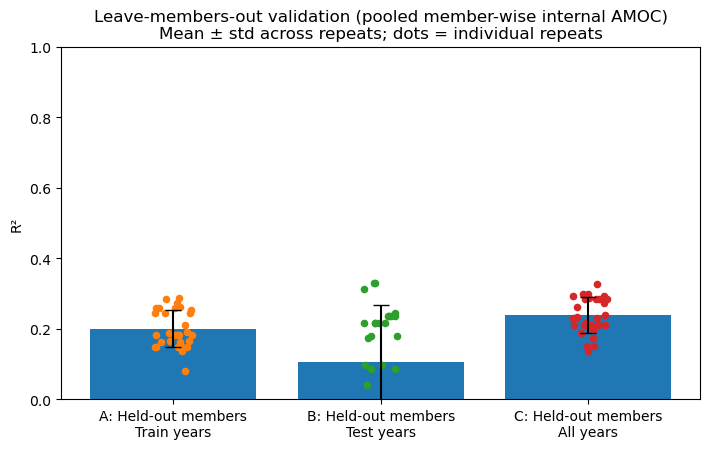

Saved: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/CESM2/AMOC_45N_member/internal_0/STEP3_leave_members_out/FIGURES/step3_r2_summary.png
Means ± std:
  A_trainYears_r2: 0.199 ± 0.053 (n=30)
  B_testYears_r2: 0.106 ± 0.161 (n=30)
  C_allYears_r2: 0.239 ± 0.050 (n=30)


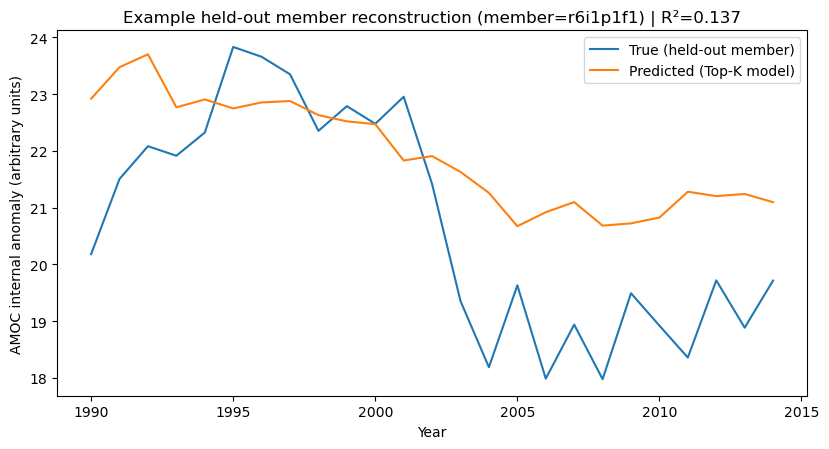

Saved: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/CESM2/AMOC_45N_member/internal_0/STEP3_leave_members_out/FIGURES/step3_holdout_timeseries.png


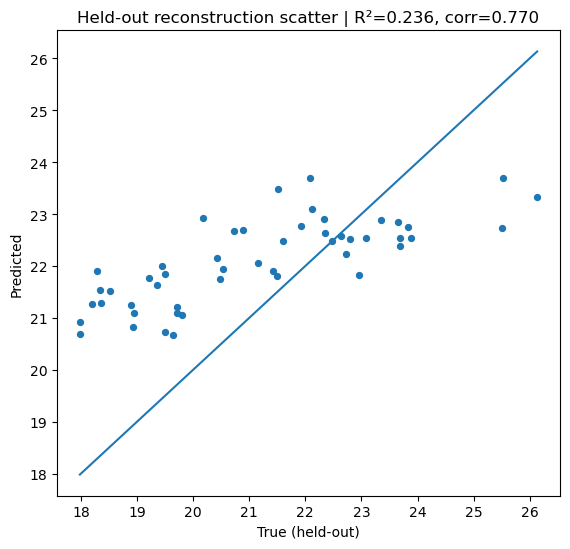

Saved: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/CESM2/AMOC_45N_member/internal_0/STEP3_leave_members_out/FIGURES/step3_holdout_scatter.png

✅ Figures written to: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/CESM2/AMOC_45N_member/internal_0/STEP3_leave_members_out/FIGURES


In [18]:
#!/usr/bin/env python3
"""
FIGURE SCRIPT — Step 3 summary (leave-members-out) + example reconstruction
===========================================================================

Reads:
  - leave_members_out_summary.csv   (R² per repeat for A/B/C)
  - holdout_example_recon.csv       (y_true/y_pred for held-out members)

Writes (in OUTDIR):
  1) step3_r2_summary.png
  2) step3_holdout_timeseries.png
  3) step3_holdout_scatter.png   (optional but very nice for supervisors)

Clean + understandable for emailing to supervisor.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score


# ============================================================
# PATHS
# ============================================================

BASE = f"/data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/CESM2/AMOC_45N_member/internal_0/STEP3_leave_members_out/"
SUMMARY_CSV = os.path.join(BASE, "leave_members_out_summary.csv")
EXAMPLE_CSV = os.path.join(BASE, "holdout_example_recon.csv")

OUTDIR = os.path.join(BASE, "FIGURES")
os.makedirs(OUTDIR, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def finite(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

def nice_label(col):
    # turn "A_trainYears" -> "A: Held-out members\nTrain years"
    if col.startswith("A_"):
        return "A: Held-out members\nTrain years"
    if col.startswith("B_"):
        return "B: Held-out members\nTest years"
    if col.startswith("C_"):
        return "C: Held-out members\nAll years"
    return col


# ============================================================
# 1) R² summary figure
# ============================================================

def make_r2_summary(summary_csv, out_png):
    df = pd.read_csv(summary_csv)

    cols = ["A_trainYears_r2", "B_testYears_r2", "C_allYears_r2"]
    data = {c: finite(df[c].values) for c in cols}

    means = [np.mean(data[c]) for c in cols]
    stds  = [np.std(data[c])  for c in cols]

    # Also show distribution as dots (per repeat)
    x = np.arange(len(cols))

    plt.figure(figsize=(7.2, 4.6))
    plt.bar(x, means, yerr=stds, capsize=6)

    # overlay individual repeats with small jitter
    rng = np.random.default_rng(0)
    for i, c in enumerate(cols):
        yy = data[c]
        jitter = (rng.random(len(yy)) - 0.5) * 0.18
        plt.scatter(np.full_like(yy, x[i], dtype=float) + jitter, yy, s=20)

    plt.xticks(x, [nice_label(c) for c in cols])
    plt.ylabel("R²")
    plt.ylim(0, 1)
    plt.title("Leave-members-out validation (pooled member-wise internal AMOC)\nMean ± std across repeats; dots = individual repeats")
    plt.tight_layout()
    plt.savefig(out_png, dpi=250)
    plt.show()

    print("Saved:", out_png)
    print("Means ± std:")
    for c, m, s in zip(cols, means, stds):
        print(f"  {c}: {m:.3f} ± {s:.3f} (n={len(data[c])})")


# ============================================================
# 2) Example held-out member timeseries figure
# ============================================================

def make_example_timeseries(example_csv, out_png):
    df = pd.read_csv(example_csv)

    # If multiple held-out members exist in the example file, pick ONE member to show cleanly
    members = sorted(df["member"].unique().tolist())
    show_member = members[0]

    d = df[df["member"] == show_member].copy()
    d = d.sort_values("year")

    y_true = d["y_true"].values
    y_pred = d["y_pred"].values
    years  = d["year"].values.astype(int)

    r2 = r2_score(y_true, y_pred) if np.isfinite(y_true).all() and np.isfinite(y_pred).all() else np.nan

    plt.figure(figsize=(8.4, 4.6))
    plt.plot(years, y_true, label="True (held-out member)")
    plt.plot(years, y_pred, label="Predicted (Top-K model)")
    plt.xlabel("Year")
    plt.ylabel("AMOC internal anomaly (arbitrary units)")
    plt.title(f"Example held-out member reconstruction (member={show_member}) | R²={r2:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=250)
    plt.show()

    print("Saved:", out_png)


# ============================================================
# 3) Scatter: predicted vs true (all rows in example file)
# ============================================================

def make_example_scatter(example_csv, out_png):
    df = pd.read_csv(example_csv)

    y_true = df["y_true"].values.astype(float)
    y_pred = df["y_pred"].values.astype(float)

    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[ok]
    y_pred = y_pred[ok]

    r2 = r2_score(y_true, y_pred) if y_true.size > 2 else np.nan
    corr = np.corrcoef(y_true, y_pred)[0, 1] if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan

    # 1:1 range
    vmin = min(np.min(y_true), np.min(y_pred))
    vmax = max(np.max(y_true), np.max(y_pred))

    plt.figure(figsize=(5.8, 5.6))
    plt.scatter(y_true, y_pred, s=18)
    plt.plot([vmin, vmax], [vmin, vmax])  # 1:1
    plt.xlabel("True (held-out)")
    plt.ylabel("Predicted")
    plt.title(f"Held-out reconstruction scatter | R²={r2:.3f}, corr={corr:.3f}")
    plt.tight_layout()
    plt.savefig(out_png, dpi=250)
    plt.show()

    print("Saved:", out_png)


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    if not os.path.exists(SUMMARY_CSV):
        raise FileNotFoundError(SUMMARY_CSV)
    if not os.path.exists(EXAMPLE_CSV):
        raise FileNotFoundError(EXAMPLE_CSV)

    make_r2_summary(SUMMARY_CSV, os.path.join(OUTDIR, "step3_r2_summary.png"))
    make_example_timeseries(EXAMPLE_CSV, os.path.join(OUTDIR, "step3_holdout_timeseries.png"))
    make_example_scatter(EXAMPLE_CSV, os.path.join(OUTDIR, "step3_holdout_scatter.png"))

    print("\n✅ Figures written to:", OUTDIR)


/tmp/ipykernel_4193076/2599125237.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


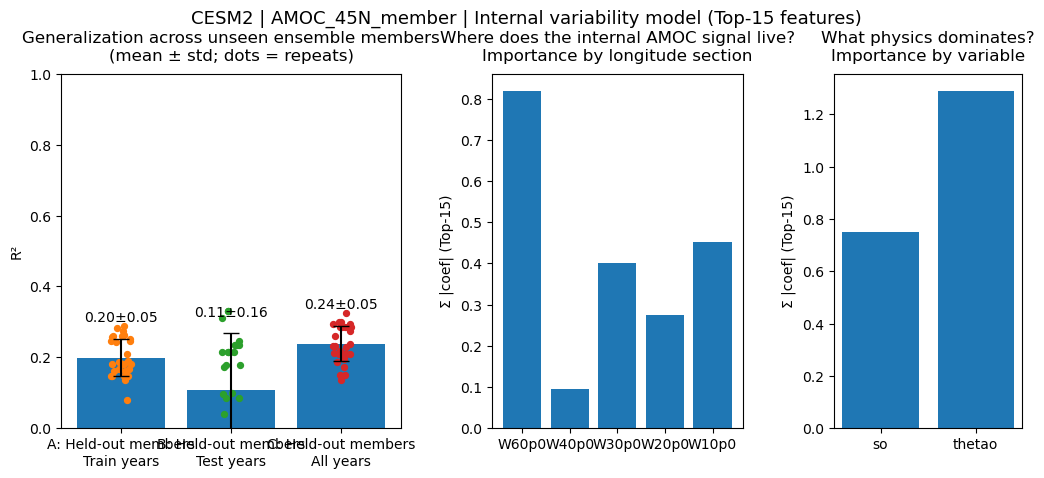

Saved: /data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/CESM2/AMOC_45N_member/internal_0/KILLER_FIGURE/step3_killer_figure_top35.png

Top-15 importance by longitude:
lon
W60p0    0.819446
W40p0    0.094153
W30p0    0.401299
W20p0    0.274097
W10p0    0.452855
Name: w, dtype: float64

Top-15 importance by variable:
var
so        0.751566
thetao    1.290284
Name: w, dtype: float64


In [20]:
#!/usr/bin/env python3
"""
KILLER FIGURE — Internal AMOC (Top-15 features) story in ONE figure
===================================================================

Panel A: Leave-members-out validation (R²) for A/B/C tests
Panel B: Where does the signal live? Importance by longitude section
Panel C: What physics dominates? Importance by variable (thetao vs so)

Inputs (existing files):
  - STEP3_leave_members_out/leave_members_out_summary.csv
  - STEP2_outputs/selected_top15.csv   (must include columns: "feature", "abscoef_std")

Output:
  - step3_killer_figure_top15.png

Notes:
  - Uses |coef| from standardized ridge (abscoef_std) as importance weight.
  - No custom colors; matplotlib defaults.
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PATHS / SETTINGS
# ============================================================

MODEL  = "CESM2"
TARGET = "AMOC_45N_member"

BASE = f"/data/users/frekle/AMOC_analysis/FEATURE_REDUCTION_POOLED/{MODEL}/{TARGET}/internal_0/"

STEP3_CSV = os.path.join(BASE, "STEP3_leave_members_out", "leave_members_out_summary.csv")
TOPK_CSV  = os.path.join(BASE, "STEP2_outputs", "selected_top35.csv")

OUTDIR = os.path.join(BASE, "KILLER_FIGURE")
os.makedirs(OUTDIR, exist_ok=True)
OUTPNG = os.path.join(OUTDIR, "step3_killer_figure_top35.png")


# ============================================================
# HELPERS
# ============================================================

def finite(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

def parse_feature_string(s):
    """
    Expected: "{var} {lon_tag} EOF{mode} lag{lag}"
    Example: "thetao W40p0 EOF6 lag0"
    """
    m = re.match(r"^(\S+)\s+(\S+)\s+EOF(\d+)\s+lag(\d+)$", str(s).strip())
    if not m:
        raise ValueError(f"Could not parse feature string: {s}")
    var, lon, mode, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
    return var, lon, mode, lag

def order_lon_tags(lon_tags):
    """
    Sort by numeric longitude magnitude if tag looks like W60p0 / E10p0.
    """
    def key(tag):
        mm = re.match(r"^([WE])(\d+)p(\d+)$", tag)
        if not mm:
            return (0, tag)
        hemi, a, b = mm.group(1), int(mm.group(2)), int(mm.group(3))
        val = a + b/10.0
        # keep West as negative for ordering left->right by longitude
        if hemi == "W":
            val = -val
        return (1, val)
    return sorted(lon_tags, key=key)

def make_panel_title(ax, title):
    ax.set_title(title, pad=10)


# ============================================================
# LOAD DATA
# ============================================================

if not os.path.exists(STEP3_CSV):
    raise FileNotFoundError(STEP3_CSV)
if not os.path.exists(TOPK_CSV):
    raise FileNotFoundError(TOPK_CSV)

df3 = pd.read_csv(STEP3_CSV)
sel = pd.read_csv(TOPK_CSV)

required_cols = {"feature", "abscoef_std"}
missing = required_cols - set(sel.columns)
if missing:
    raise ValueError(f"{TOPK_CSV} is missing columns: {missing}. "
                     f"Re-run Step 2 so selected_top15.csv includes abscoef_std.")

# parse features
parsed = [parse_feature_string(s) for s in sel["feature"].values]
sel["var"] = [p[0] for p in parsed]
sel["lon"] = [p[1] for p in parsed]
sel["mode"] = [p[2] for p in parsed]
sel["lag"]  = [p[3] for p in parsed]

# importance weights
sel["w"] = sel["abscoef_std"].astype(float)

# aggregates
imp_by_lon = sel.groupby("lon")["w"].sum().sort_index()
imp_by_var = sel.groupby("var")["w"].sum().sort_index()

# nicer longitude order
lon_order = order_lon_tags(list(imp_by_lon.index))
imp_by_lon = imp_by_lon.reindex(lon_order)

# Step 3 R² columns
cols_r2 = [
    ("A_trainYears_r2", "A: Held-out members\nTrain years"),
    ("B_testYears_r2",  "B: Held-out members\nTest years"),
    ("C_allYears_r2",   "C: Held-out members\nAll years"),
]


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12.4, 4.6))
gs = plt.GridSpec(1, 3, width_ratios=[1.35, 1.0, 0.75], wspace=0.35)

# -------- Panel A: R² summary --------
ax1 = plt.subplot(gs[0, 0])

means, stds, allvals = [], [], []
for c, _ in cols_r2:
    v = finite(df3[c].values)
    allvals.append(v)
    means.append(np.mean(v))
    stds.append(np.std(v))

x = np.arange(len(cols_r2))
ax1.bar(x, means, yerr=stds, capsize=6)

# dots for repeats
rng = np.random.default_rng(0)
for i, v in enumerate(allvals):
    jitter = (rng.random(len(v)) - 0.5) * 0.18
    ax1.scatter(np.full_like(v, x[i], dtype=float) + jitter, v, s=18)

ax1.set_xticks(x)
ax1.set_xticklabels([lab for _, lab in cols_r2])
ax1.set_ylabel("R²")
ax1.set_ylim(0, 1)
make_panel_title(ax1, "Generalization across unseen ensemble members\n(mean ± std; dots = repeats)")

# annotate means
for i, (m, s) in enumerate(zip(means, stds)):
    ax1.text(i, min(0.98, m + s + 0.04), f"{m:.2f}±{s:.2f}", ha="center", va="bottom", fontsize=10)


# -------- Panel B: Importance by longitude --------
ax2 = plt.subplot(gs[0, 1])

ax2.bar(np.arange(len(imp_by_lon)), imp_by_lon.values)
ax2.set_xticks(np.arange(len(imp_by_lon)))
ax2.set_xticklabels(list(imp_by_lon.index), rotation=0)
ax2.set_ylabel("Σ |coef| (Top-15)")
make_panel_title(ax2, "Where does the internal AMOC signal live?\nImportance by longitude section")

# -------- Panel C: Importance by variable --------
ax3 = plt.subplot(gs[0, 2])

ax3.bar(np.arange(len(imp_by_var)), imp_by_var.values)
ax3.set_xticks(np.arange(len(imp_by_var)))
ax3.set_xticklabels(list(imp_by_var.index))
ax3.set_ylabel("Σ |coef| (Top-15)")
make_panel_title(ax3, "What physics dominates?\nImportance by variable")

# -------- Figure title / footer --------
plt.suptitle(f"{MODEL} | {TARGET} | Internal variability model (Top-15 features)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPNG, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", OUTPNG)
print("\nTop-15 importance by longitude:")
print(imp_by_lon)
print("\nTop-15 importance by variable:")
print(imp_by_var)


✅ Feature matrix rebuilt: (162, 3)


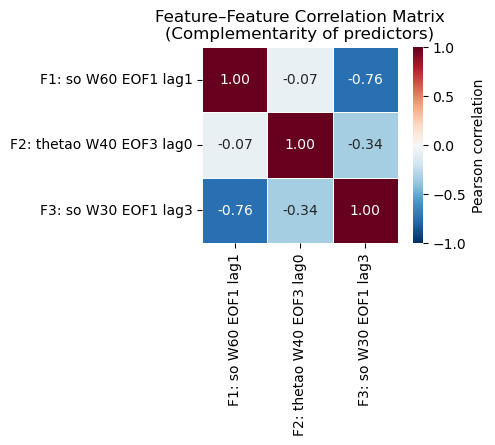

✅ Saved: fig_feature_feature_correlation.png


In [2]:
#!/usr/bin/env python3
"""
FEATURE–FEATURE CORRELATION MATRIX
Shows complementarity of the 3 selected predictors
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# PATHS
# --------------------------------------------------
RECON_CSV = (
    "/data/users/frekle/AMOC_analysis/THESIS_FIGURES/"
    "IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/CUSTOM_FEATURES/"
    "IPSL-CM6A-LR_AMOC_45N_ensmean_custom3_reconstruction.csv"
)

# --------------------------------------------------
# FEATURE DEFINITIONS (must match reconstruction order)
# --------------------------------------------------
FEATURE_NAMES = [
    "F1: so W60 EOF1 lag1",
    "F2: thetao W40 EOF3 lag0",
    "F3: so W30 EOF1 lag3",
]

# --------------------------------------------------
# LOAD RECONSTRUCTION + PCs USED
# --------------------------------------------------
df = pd.read_csv(RECON_CSV)

# Only use years actually used in regression (after max lag)
df = df[df["is_used"]].copy()

# ==========================================================
# BUILD FEATURE MATRIX DIRECTLY FROM EOF PCs
# (same logic as reconstruction script)
# ==========================================================
3
# --------------------------------------------------
# SETTINGS — must match reconstruction
# --------------------------------------------------
MODEL  = "IPSL-CM6A-LR"
MODE   = "ensmean"

EOF_DIR = (
    "/data/projects/nckf/frekle/EOF_results/"
    "IPSL-CM6A-LR/latdepth_sections/Train_period_85pct/"
)

# IMPORTANT — must match feature order in reconstruction
FEATURES = [
    ("so",     "W60p0", 0, 1),   # F1
    ("thetao", "W40p0", 2, 0),   # F2
    ("so",     "W30p0", 0, 3),   # F3
]

FEATURE_NAMES = [
    "F1: so W60 EOF1 lag1",
    "F2: thetao W40 EOF3 lag0",
    "F3: so W30 EOF1 lag3",
]

# --------------------------------------------------
# HELPER: load PC
# --------------------------------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(var, lon_tag):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].mean("member")   # ensmean
    PC = PC.transpose("time","mode")

    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years))
    PC = PC.swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC.values.astype(float), years

# --------------------------------------------------
# LOAD ALL REQUIRED PCs
# --------------------------------------------------
pc_np = {}
years_common = None

for (var, lon, _, _) in FEATURES:
    pc, years = load_pc(var, lon)
    pc_np[(var,lon)] = pc

    if years_common is None:
        years_common = years
    else:
        years_common = np.intersect1d(years_common, years)

years_common = np.sort(years_common)

# Align PCs on common years
for k in pc_np:
    # reload aligned to years_common
    ds = xr.open_dataset(os.path.join(
        EOF_DIR, f"EOF_latdepth_{k[0]}_{k[1]}.nc"))
    PC = ds["PC"].mean("member").transpose("time","mode")
    yrs = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", yrs)).swap_dims({"time":"year"}).drop_vars("time")
    pc_np[k] = PC.sel(year=years_common).values.astype(float)
    ds.close()

# --------------------------------------------------
# APPLY LAGS (exactly like reconstruction)
# --------------------------------------------------
maxlag = max(lag for *_, lag in FEATURES)
used_global = np.arange(maxlag, len(years_common))

X = np.empty((len(used_global), len(FEATURES)))

for j,(var,lon,m0,lag) in enumerate(FEATURES):
    X[:,j] = pc_np[(var,lon)][used_global - lag, m0]

# Convert to DataFrame
X = pd.DataFrame(X, columns=FEATURE_NAMES)

print("✅ Feature matrix rebuilt:", X.shape)


# --------------------------------------------------
# CORRELATION MATRIX
# --------------------------------------------------
corr = X.corr()

# --------------------------------------------------
# PLOT
# --------------------------------------------------
plt.figure(figsize=(5.5, 4.5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws=dict(label="Pearson correlation"),
    linewidths=0.5
)

plt.title("Feature–Feature Correlation Matrix\n(Complementarity of predictors)")
plt.tight_layout()
#plt.savefig("fig_feature_feature_correlation.png", dpi=300)
plt.show()

print("✅ Saved: fig_feature_feature_correlation.png")


In [ ]:
#!/usr/bin/env python3
"""
FEATURE DIAGNOSTIC FIGURES
-------------------------------------------------
A) Feature–feature correlation: Top-3-by-corr
B) PCA of chosen 3 features
C) Partial correlations vs AMOC
-------------------------------------------------
Uses EXACT same PCs + lags as reconstruction
"""

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ============================================================
# SETTINGS  (must match reconstruction)
# ============================================================

MODEL = "IPSL-CM6A-LR"
EOF_DIR = "/data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/latdepth_sections/Train_period_85pct/"
AMOC_FILE = "/data/users/frekle/AMOC_analysis/AMOC_IPSL-CM6A-LR.nc"

TARGET = "AMOC_45N_ensmean"

# ---- YOUR CHOSEN FEATURES ----
FEATS_CHOSEN = [
    ("so","W60p0",0,1),   # F1
    ("thetao","W40p0",2,0), # F2
    ("so","W30p0",0,3),   # F3
]

NAMES_CHOSEN = ["F1","F2","F3"]

# ---- TOP-3 BY CORRELATION (from ranking list) ----
FEATS_TOP3 = [
    ("so","W60p0",0,1),
    ("so","W60p0",0,2),
    ("so","W60p0",0,8),
]

NAMES_TOP3 = ["T1","T2","T3"]

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], int)

def load_pc(var,lon):
    f = os.path.join(EOF_DIR,f"EOF_latdepth_{var}_{lon}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].mean("member").transpose("time","mode")
    yrs = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time",yrs)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return PC

def load_amoc():
    ds = xr.open_dataset(AMOC_FILE)
    y = ds[TARGET].mean("member").squeeze()
    yrs = extract_years(y["time"])
    y = y.assign_coords(year=("time",yrs)).swap_dims({"time":"year"}).drop_vars("time")
    ds.close()
    return y

def build_feature_matrix(feats):

    pc_dict = {}
    years_common = None

    for (v,l,_,_) in feats:
        pc = load_pc(v,l)
        pc_dict[(v,l)] = pc

        if years_common is None:
            years_common = pc["year"].values
        else:
            years_common = np.intersect1d(years_common, pc["year"].values)

    years_common = np.sort(years_common)

    for k in pc_dict:
        pc_dict[k] = pc_dict[k].sel(year=years_common).values

    maxlag = max(lag for *_,lag in feats)
    used = np.arange(maxlag,len(years_common))

    X = np.empty((len(used),len(feats)))

    for j,(v,l,m0,lag) in enumerate(feats):
        X[:,j] = pc_dict[(v,l)][used-lag,m0]

    return X, years_common[used]

# ============================================================
# LOAD DATA
# ============================================================

X_chosen, years = build_feature_matrix(FEATS_CHOSEN)
X_top3 , _      = build_feature_matrix(FEATS_TOP3)

amoc = load_amoc().sel(year=years).values

# standardize for diagnostics
scaler = StandardScaler()
Xc = scaler.fit_transform(X_chosen)
Xt = scaler.fit_transform(X_top3)

# ============================================================
# FIGURE A — TOP3 CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(4.8,4))
sns.heatmap(
    pd.DataFrame(Xt,columns=NAMES_TOP3).corr(),
    annot=True, cmap="RdBu_r", vmin=-1, vmax=1, square=True
)
plt.title("Top-3-by-correlation features\n(nearly collinear)")
plt.tight_layout()
plt.savefig("figA_top3_corrmatrix.png",dpi=300)
plt.show()

# ============================================================
# FIGURE B — PCA OF CHOSEN FEATURES
# ============================================================

pca = PCA().fit(Xc)
var = pca.explained_variance_ratio_

plt.figure(figsize=(5,4))
plt.bar([1,2,3],var)
plt.xlabel("Principal component")
plt.ylabel("Explained variance")
plt.title("Variance spread across PCs (Chosen features)")
plt.tight_layout()
plt.savefig("figB_pca_variance.png",dpi=300)
plt.show()

# ============================================================
# FIGURE C — PARTIAL CORRELATIONS
# ============================================================

def partial_corr(x,y,others):

    reg = LinearRegression()
    reg.fit(others,x)
    x_res = x - reg.predict(others)

    reg.fit(others,y)
    y_res = y - reg.predict(others)

    return np.corrcoef(x_res,y_res)[0,1]

partials = []

for i in range(3):
    others = np.delete(Xc,i,axis=1)
    pc = partial_corr(Xc[:,i],amoc,others)
    partials.append(pc)

plt.figure(figsize=(5,4))
plt.bar(NAMES_CHOSEN,partials)
plt.ylabel("Partial correlation with AMOC")
plt.title("Conditional contribution of each feature")
plt.tight_layout()
plt.savefig("figC_partial_corr.png",dpi=300)
plt.show()

print("\n✅ Diagnostic figures saved:")
print("  figA_top3_corrmatrix.png")
print("  figB_pca_variance.png")
print("  figC_partial_corr.png")


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


OSError: [Errno -101] NetCDF: HDF error: '/data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/latdepth_sections/Train_period_85pct/EOF_latdepth_so_W60p0.nc'